In [184]:
#Uploading useful libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import norm
from pprint import pprint
from copy import deepcopy
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, confusion_matrix, balanced_accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
warnings.filterwarnings('ignore')
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, HistGradientBoostingClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import PolynomialFeatures
%matplotlib inline
from sklearn.feature_selection import RFECV
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Loading the dataset and brief analysis of the variables


In [185]:
#loading data
data_train = pd.read_csv("train.csv")

#Let's try to visualize the dataset and understand how it is made up
data_train.head()

data_train.shape #112500 observations, 12 variables
num_obs = data_train.shape[0]

In [186]:
#understanding the variables:
data_train.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In the initial stage, we decided to do a brief analysis on each variable

variables:
- 'SeriousDlqin2yrs': binary variable
- 'RevolvingUtilizationOfUnsecuredLines': percentage
- 'age': count data (int)
- 'NumberOfTime30-59DaysPastDueNotWorse':count data(int)
- 'DebtRatio': percentage
- 'MonthlyIncome': real
- 'NumberOfOpenCreditLinesAndLoans':count data(int)
- 'NumberOfTimes90DaysLate': count data(int)
- 'NumberRealEstateLoansOrLines':count data(int)
- 'NumberOfTime60-89DaysPastDueNotWorse': count data(int)
- 'NumberOfDependents': count data(int)

For each variable:
- we print the summary
- we count the NAs
- we plot them graphically
- we analye the outliers

In [187]:
#Summary for each variable
data_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,112500.0,56249.500000,32476.096979,0.0,28124.750000,56249.500000,84374.250000,1.124990e+05
SeriousDlqin2yrs,112500.0,0.066844,0.249754,0.0,0.000000,0.000000,0.000000,1.000000e+00
RevolvingUtilizationOfUnsecuredLines,112500.0,6.264202,259.629816,0.0,0.029678,0.153517,0.558305,5.070800e+04
age,112500.0,52.468098,14.799413,-1.0,41.000000,52.000000,63.000000,1.030000e+02
NumberOfTime30-59DaysPastDueNotWorse,112500.0,0.421351,4.196450,0.0,0.000000,0.000000,0.000000,9.800000e+01
DebtRatio,112500.0,353.833079,2153.220951,0.0,0.175078,0.366299,0.857619,3.296640e+05
MonthlyIncome,90313.0,6328.071744,14134.143590,0.0,3227.141249,5112.461788,7812.482023,2.866006e+06
NumberOfOpenCreditLinesAndLoans,112500.0,8.462951,5.150260,0.0,5.000000,8.000000,11.000000,5.800000e+01
NumberOfTimes90DaysLate,112500.0,0.266764,4.173038,0.0,0.000000,0.000000,0.000000,9.800000e+01
NumberRealEstateLoansOrLines,112500.0,1.018231,1.133211,0.0,0.000000,1.000000,2.000000,5.400000e+01


In [188]:
#That there is one observation where the value of age is -1
print(data_train[data_train["age"] == -1].index)

#We remove it:
data_train = data_train[data_train["age"] != -1]
num_obs = data_train.shape[0] #112499

Index([5005], dtype='int64')


In [189]:
#Number of missing values for variable
#Counts
na_counts = data_train.isna().sum()

#Percentage
na_percentage = (na_counts / len(data_train)) * 100

# Combine the counts and percentages into a DataFrame for a clearer presentation
na_summary = pd.DataFrame({
    'NA Count': na_counts,
    'NA Percentage': na_percentage
})

print(na_summary)

                                      NA Count  NA Percentage
Unnamed: 0                                   0       0.000000
SeriousDlqin2yrs                             0       0.000000
RevolvingUtilizationOfUnsecuredLines         0       0.000000
age                                          0       0.000000
NumberOfTime30-59DaysPastDueNotWorse         0       0.000000
DebtRatio                                    0       0.000000
MonthlyIncome                            22187      19.721953
NumberOfOpenCreditLinesAndLoans              0       0.000000
NumberOfTimes90DaysLate                      0       0.000000
NumberRealEstateLoansOrLines                 0       0.000000
NumberOfTime60-89DaysPastDueNotWorse         0       0.000000
NumberOfDependents                        2945       2.617801


**GRAPHICAL ANALYSIS**

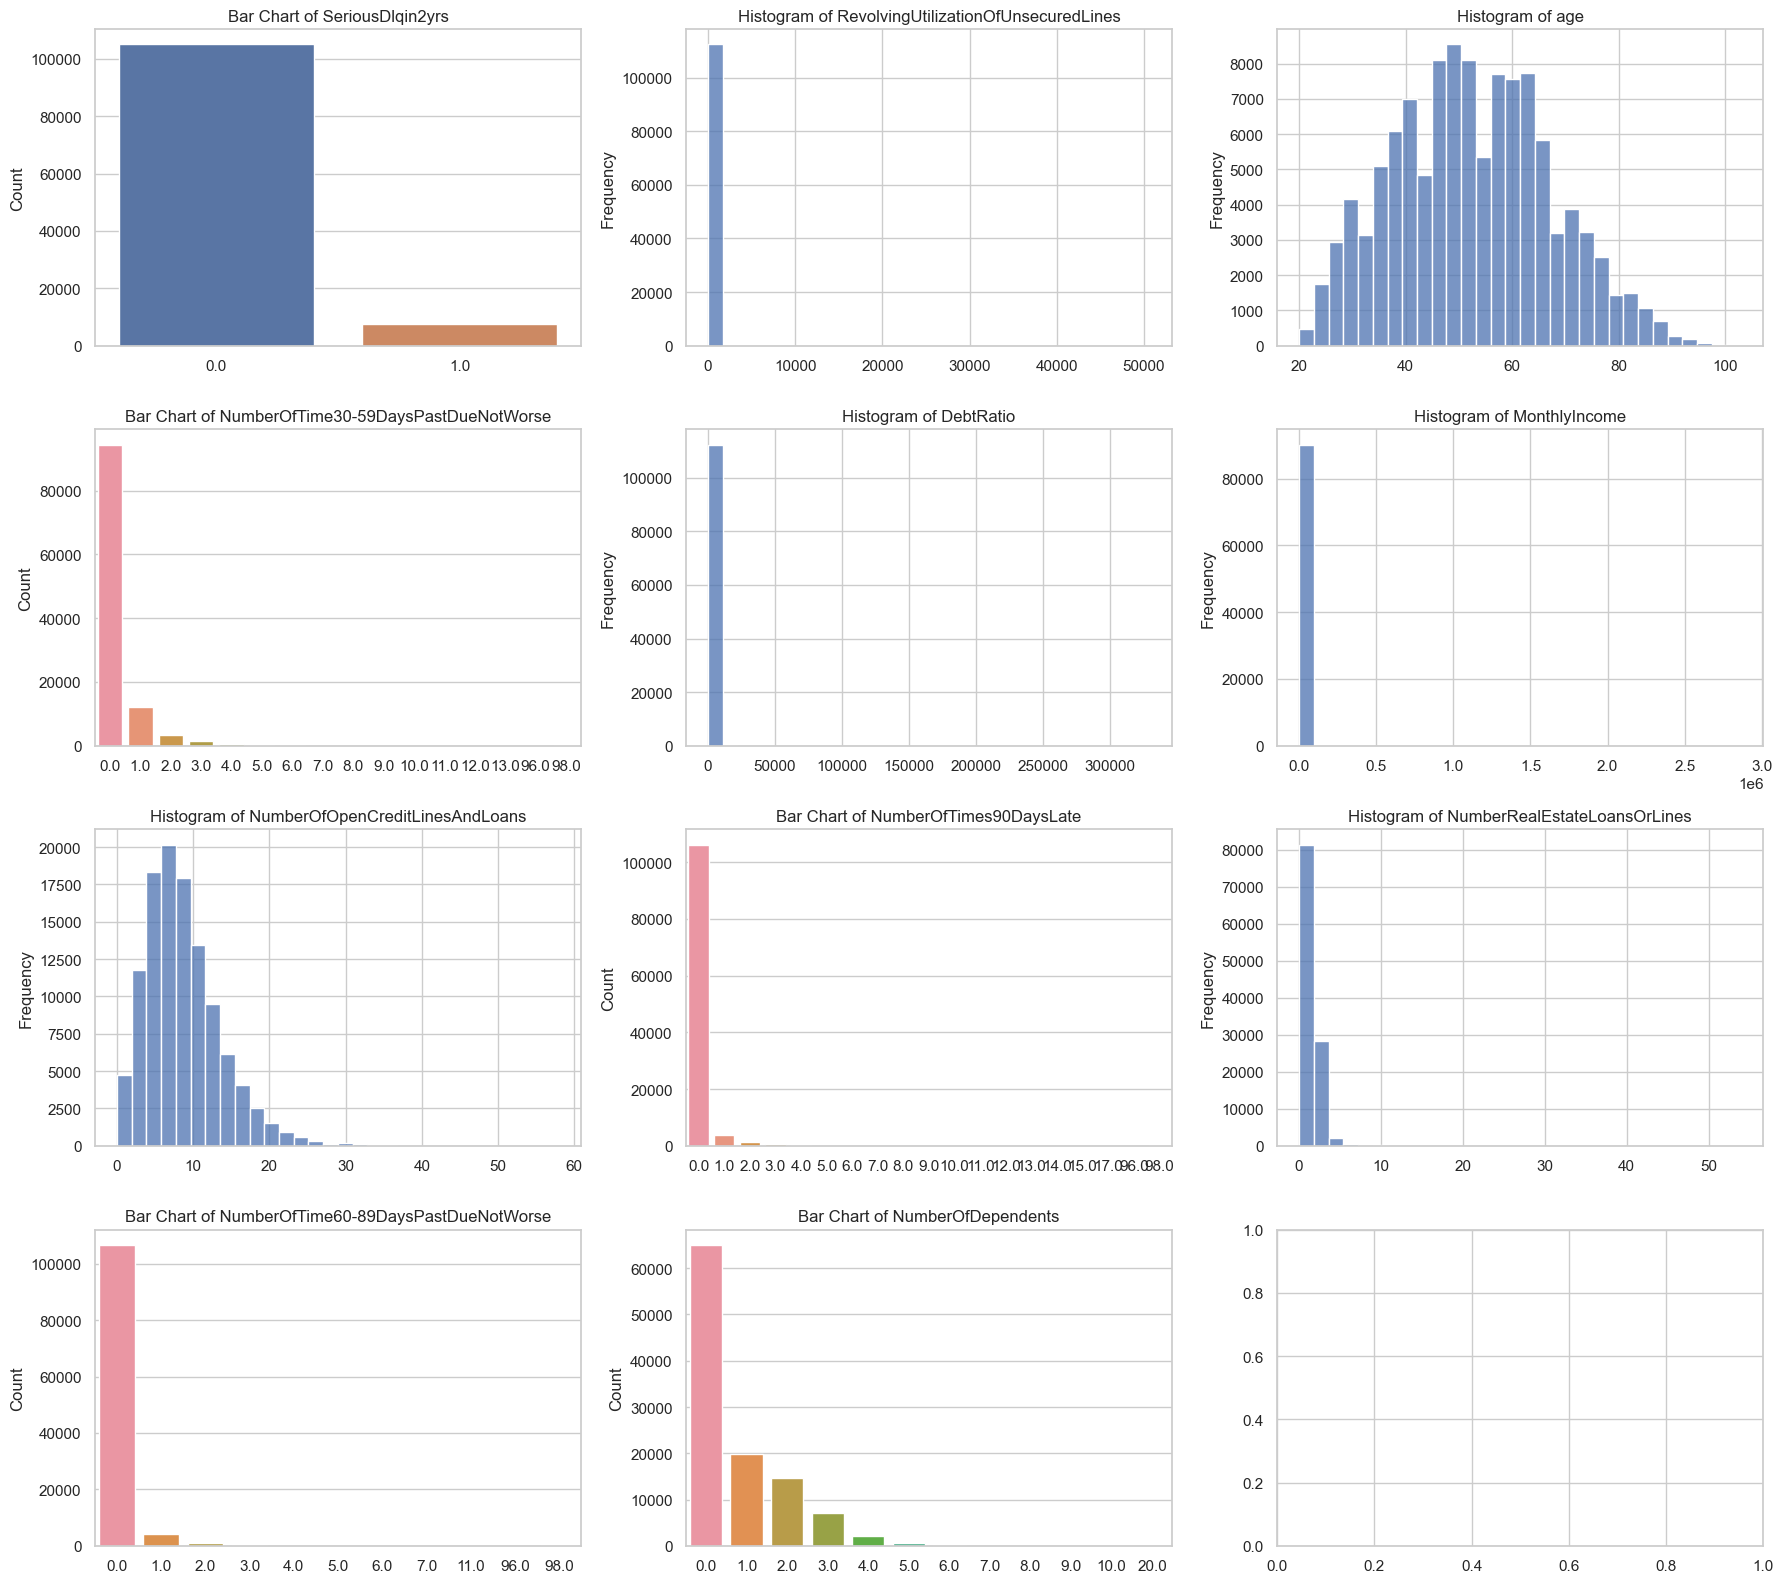

In [190]:
sns.set(style="whitegrid")
columns = data_train.columns[1:]  # exclue 'Unnamed: 0'

#subplots
n_cols = 3
n_rows = n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))
fig.tight_layout(pad=4.0)

# Loop through the variables and create a plot for each one
for i, col in enumerate(columns):
    ax = axes[i // n_cols, i % n_cols]
    if len(data_train[col].unique()) < 20:
        # If the variable has less than 20 unique values, plot a bar chart
        sns.countplot(x=col, data=data_train, ax=ax)
        ax.set_title(f'Bar Chart of {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Count')
    else:
        # If the variable is numerical, plot a histogram
        sns.histplot(data_train[col], bins=30 , kde=False, ax=ax)
        ax.set_title(f'Histogram of {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


# Imputing


variables with NAs:
- num_dependents (0.026%)
- monthly_income (19.72%)

**NUMDEPENDENTS VARIABLE**

Since the amount of missing data is almost insignificant (0.026%), we replace it with the value of the median

In [236]:
num_dependents = data_train["NumberOfDependents"]
median_dependents = num_dependents.median()
num_dependents.fillna(median_dependents, inplace=True)

**MONTHLY INCOME VARIABLE**

For the large amount of missing data, we decided to run a graphical analysis to understand if the missing data of monthly_income is somehow related to the other variables, or if the presence of missing data is independent and at random.

In [210]:
#We create a variable monthly_income_nas: it is a binary variable that takes value 1 for
#the observation that do not have MonthlyIncome
monthly_income_nas = data_train["MonthlyIncome"].isna()
monthly_income_nas.head()

0    False
1     True
2    False
3    False
4     True
Name: MonthlyIncome, dtype: bool

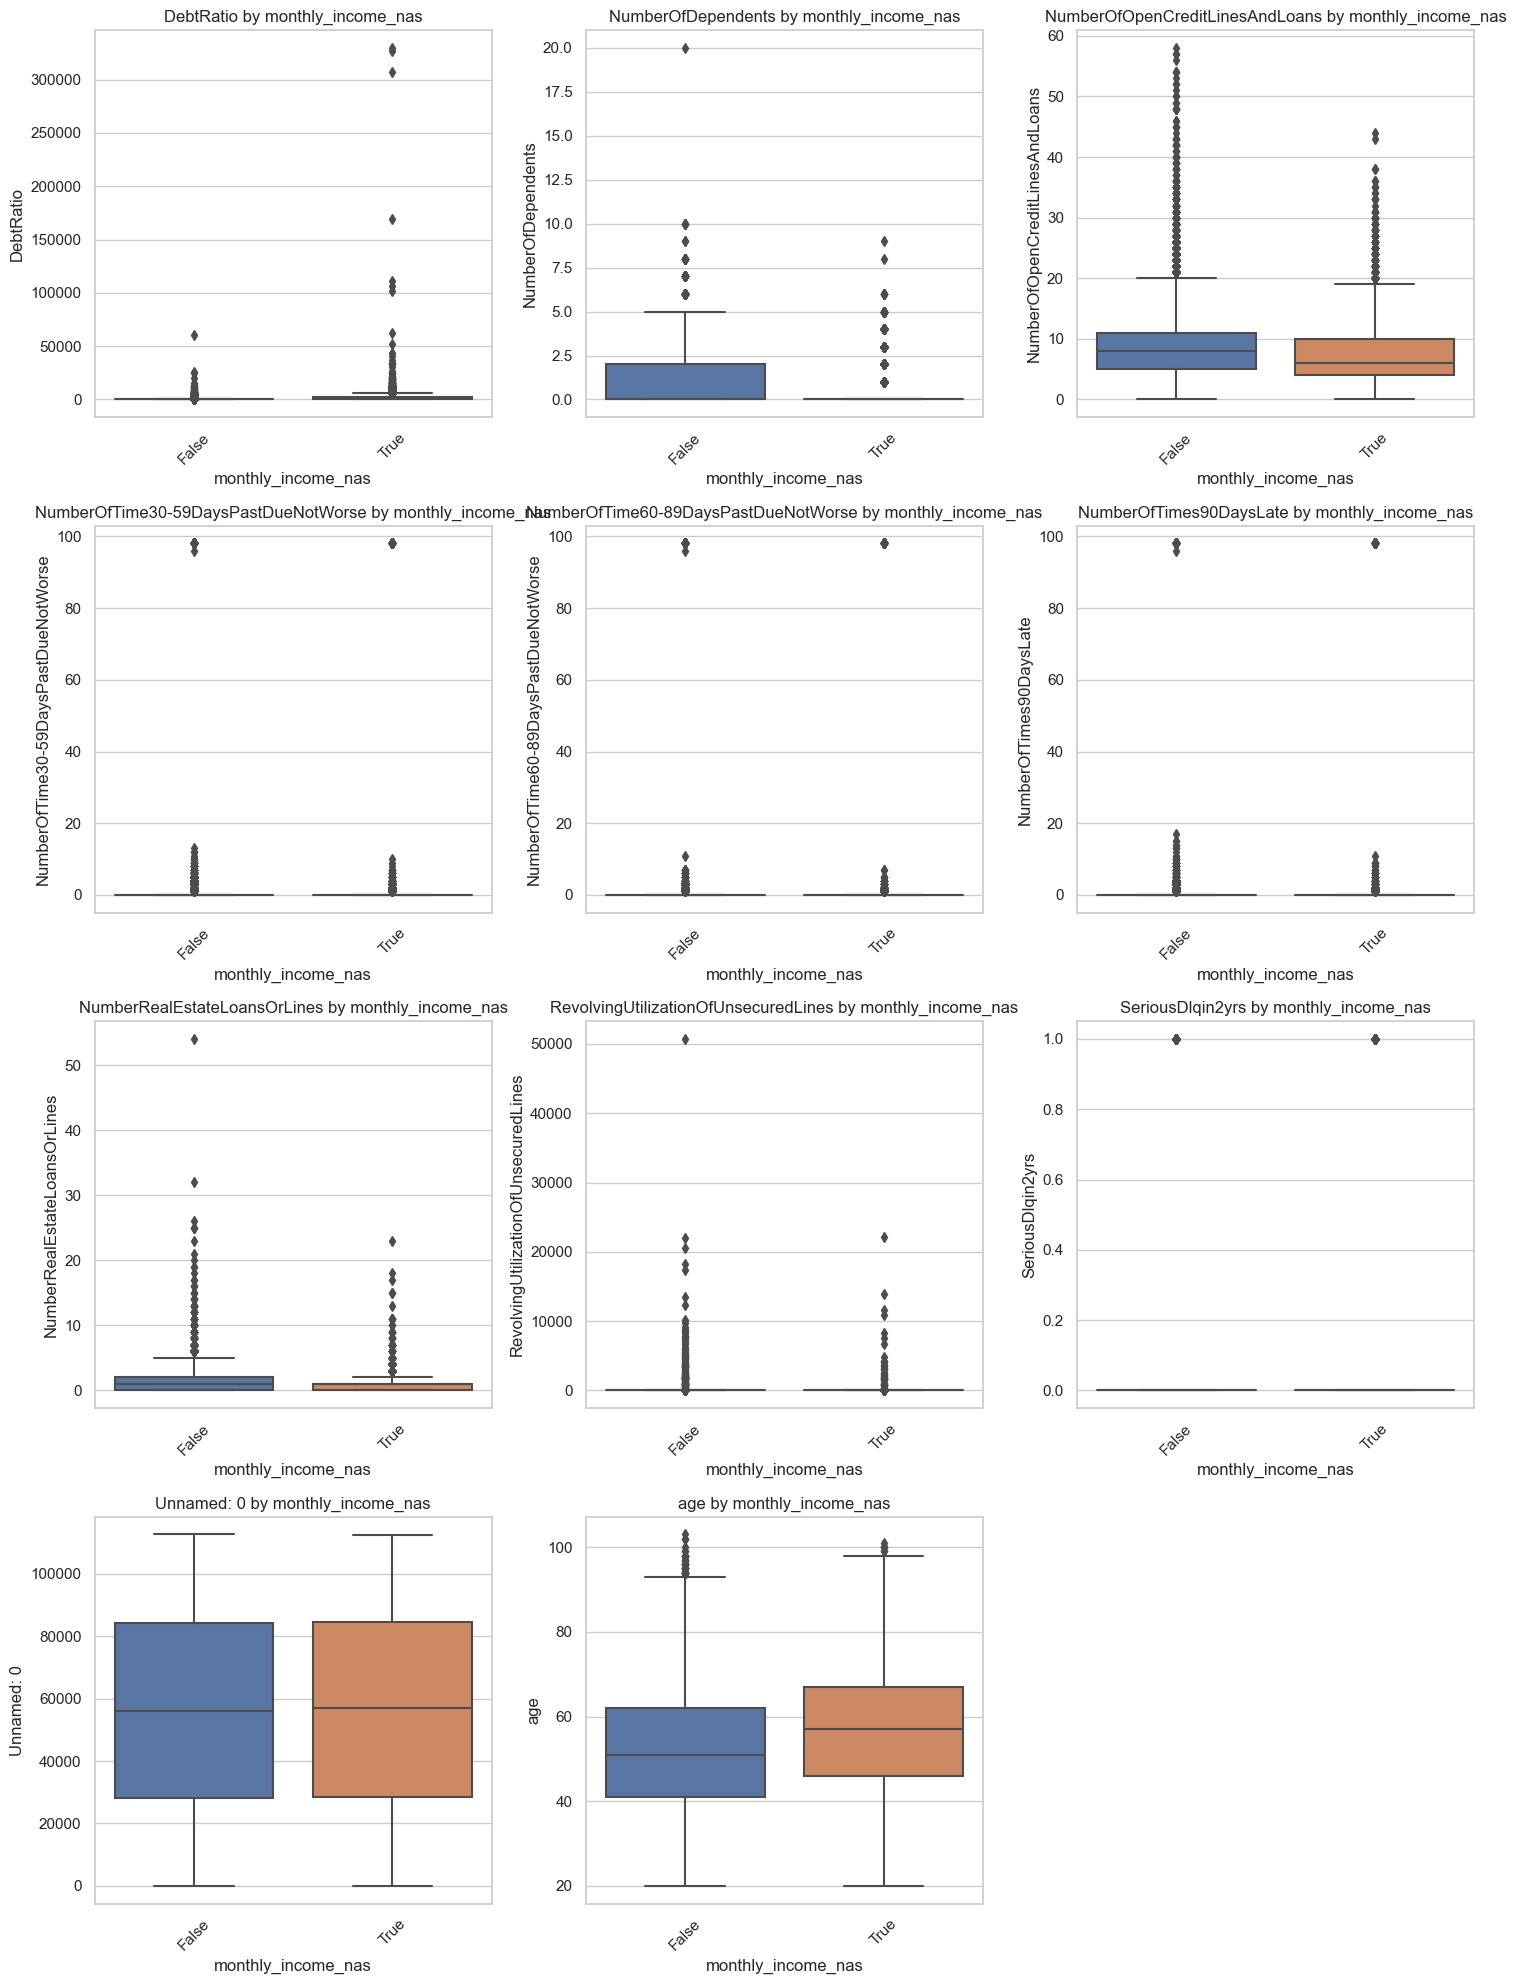

In [232]:
#add monthly_income_nas to training set
data_train['monthly_income_nas'] = monthly_income_nas
variables_to_plot = data_train.columns.difference(['MonthlyIncome', 'monthly_income_nas'])

#subplot grid
n_vars = len(variables_to_plot)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

# boxplot for each variable
for i, variable in enumerate(variables_to_plot):
    sns.boxplot(x='monthly_income_nas', y=variable, data=data_train, ax=axes[i])
    axes[i].set_title(f'{variable} by monthly_income_nas')
    axes[i].tick_params(axis='x', labelrotation=45)

for ax in axes[len(variables_to_plot):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# remove 'monthly_income_nas'
data_train.drop('monthly_income_nas', axis=1, inplace=True)


We notice that missing income data might be associated with higher financial activity (credit lines, credit utilization and high debt ratios),  suggests that missingness is not random but related to observable variables. This recognition leads us to try not only simpler imputaion methods, but also model-based imputation techniques, such as KNN imputation and Iterative Imputer with Random Forest, which can effectively utilize the underlying patterns and relationships in the data to predict missing values more accurately and realistically.

To choose the best imputing method for handling NA in the monthly_income variable, we try four alternatives:
- median imputation
- mean imputation
- KNN imputation
- Iterative imputer + random forest

We use a "create_missing_values" function for simulating missing data scenarios in machine learning experiments where missing data handling techniques need to be evaluated.

Then we build "Update_metrics" for tracking the performance of a model in imputing missing values by evaluating how close its imputed values are to the ground truth values, using MAE and MSE metrics, for each missing index

In [253]:
#loading data
data_to_impute = data_train.copy()

# remove the columns
columns_to_drop = ['Unnamed: 0', 'SeriousDlqin2yrs']
data_to_impute.drop(columns_to_drop, axis=1, inplace=True)
length_of_dataset = data_to_impute.shape[0]

# calculate number of missing values by column
missing_values_by_column = data_to_impute.isna().sum()
prc_missing_values_by_column = missing_values_by_column / length_of_dataset

# drop missing values
data_to_impute.dropna(inplace=True)

# split the data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(data_to_impute, test_size=0.2, random_state=0) # 80% train, 20% test both with no missing values
#create a copy of X_train that we will use later to train our Random Forest regressor
data_train_rf = X_train.copy(deep=True)
X_train, X_test = X_train.values, X_test.values # convert to numpy arrays
y_train, y_test = np.copy(X_train), np.copy(X_test) # copy the test data to use as the ground truth


# assert there are n0 missing values in any of the datasets
assert np.isnan(X_train).sum() == 0
assert np.isnan(X_test).sum() == 0
assert np.isnan(y_train).sum() == 0
assert np.isnan(y_test).sum() == 0

del data_to_impute

In [254]:
def create_missing_values(X, prc_missing_values_by_column, columns_to_introduce_missing, column_names=None, seed=0):
    np.random.seed(seed)
    # create a boolean array of the size of the data
    missing_value_mask = np.zeros(X.shape, dtype=bool)

    for column_index in columns_to_introduce_missing:
        prc_missing = prc_missing_values_by_column[column_index]

        # calculate how many missing values to create
        n_to_nan = int(prc_missing * X.shape[0])

        # randomly select n_missing indexes for the column
        idx = np.random.choice(X.shape[0], n_to_nan, replace=False)
        missing_value_mask[idx, column_index] = True

    # create the missing values
    X[missing_value_mask] = np.nan

    return X, missing_value_mask

# Get the column index for the specified column name
column_name = 'MonthlyIncome'
# If X_train is a NumPy array, you need to provide the column index directly
column_index = 4  # For example, assuming 'MonthlyIncome' is at index 4

# Specify the columns to introduce missing values based on their indices
columns_to_introduce_missing = [column_index]

# create missing values in the train data
X_train, missing_value_mask_train = create_missing_values(X_train.copy(), prc_missing_values_by_column, columns_to_introduce_missing)

# create missing values in the test data
X_test, missing_value_mask_test = create_missing_values(X_test.copy(), prc_missing_values_by_column, columns_to_introduce_missing)


In [255]:
def update_metrics(metrics_df, X_test_imputed, y, mask, model_name, strategy=None):
    """
    Update the metrics dataframe with Mean Absolute Error (MAE) and Mean Squared Error (MSE) for each missing index.

    Parameters:
    - metrics_df (pandas.DataFrame): The metrics dataframe to update.
    - X_test_imputed (numpy.ndarray): The imputed test data.
    - y (numpy.ndarray): The ground truth test data.
    - mask (numpy.ndarray): The mask indicating missing values.
    - model_name (str): The name of the model.
    - strategy (str): The imputation strategy used by the model. Default is None.

    Returns:
    - metrics_df (pandas.DataFrame): The updated metrics dataframe.
    """
    missing_idx = np.unique(np.where(mask)[1])
    for i in missing_idx:
        mae = np.mean(np.abs(X_test_imputed[mask[:, i], i] - y[mask[:, i], i]))
        mse = np.mean((X_test_imputed[mask[:, i], i] - y[mask[:, i], i])**2)

        # If the model name is "SimpleImputer" and strategy is provided, append the strategy to the model name
        if model_name == "SimpleImputer" and strategy is not None:
            model_name = f"{strategy}Imputer"

        metrics_df.loc[model_name, f'mae_{i}'] = mae
        metrics_df.loc[model_name, f'mse_{i}'] = mse

    return metrics_df





Mean Imputer

In [256]:
#Build the Mean Imputer
# impute the data with the simple imputer

imputer = SimpleImputer(strategy='mean')

# fit the imputer
imputer.fit(X_train.copy())

# create a dataframe to store the metrics
missing_idx = np.unique(np.where(missing_value_mask_test)[1])
columns_of_df = [f'mae_{i}' for i in missing_idx] + [f'mse_{i}' for i in missing_idx]
metrics = pd.DataFrame(columns=columns_of_df)

# impute the data
X_test_imputed = imputer.transform(X_test.copy())

# calculate mae and mse for the imputed data for each column in the missing_idx
metrics1 = update_metrics(metrics, X_test_imputed, y_test, missing_value_mask_test, 'MeanImputer')
print(metrics1)


                   mae_4             mse_4
MeanImputer  3663.457385  138139958.767207


Median Imputer

In [257]:
#Build the Median Imputer
# impute the data with the simple imputer
imputer = SimpleImputer(strategy='median')

# fit the imputer
imputer.fit(X_train.copy())

# create a dataframe to store the metrics
missing_idx = np.unique(np.where(missing_value_mask_test)[1])
columns_of_df = [f'mae_{i}' for i in missing_idx] + [f'mse_{i}' for i in missing_idx]
metrics = pd.DataFrame(columns=columns_of_df)

# impute the data
X_test_imputed = imputer.transform(X_test.copy())

# calculate mae and mse for the imputed data for each column in the missing_idx
metrics2 = update_metrics(metrics, X_test_imputed, y_test, missing_value_mask_test, 'MedianImputer')
print(metrics2)


                     mae_4             mse_4
MedianImputer  3513.421117  140263692.961205


KNN imputer

In [217]:
data_train_knn = X_train.copy()

grid = [{
        'n_neighbors': [3, 5, 6,  7],
    'weights': ['uniform', 'distance'],
    'metric': ['nan_euclidean']}
]

model_tuned = KNNImputer()

grid_search_knn= GridSearchCV(model_tuned, grid, cv=5,
                               scoring='accuracy',
                               return_train_score=True)
# fit the imputer
grid_search_knn.fit(data_train_knn)


# create a dataframe to store the metrics
missing_idx = np.unique(np.where(missing_value_mask_test)[1])
columns_of_df = [f'mae_{i}' for i in missing_idx] + [f'mse_{i}' for i in missing_idx]
metrics = pd.DataFrame(columns=columns_of_df)

# impute the data
X_test_imputed = grid_search_knn.transform(X_test.copy())

# calculate mae and mse for the imputed data for each column in the missing_idx
metrics3 = update_metrics(metrics, X_test_imputed, y_test, missing_value_mask_test, 'KNNImputer')
print(metrics3)

                  mae_4             mse_4
KNNImputer  3651.748109  396951168.651743


Iterative Imputer with random Forest

In [258]:
# Create the IterativeImputer object using RandomForestRegressor as the estimator
imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                           missing_values=np.nan,
                           max_iter=10,
                           random_state=0,
                           imputation_order='ascending')

# Fit the imputer on the training data
imputer.fit(X_train.copy())

# Impute the data
X_test_imputed = imputer.transform(X_test.copy())

# Create a dataframe to store the metrics
missing_idx = np.unique(np.where(missing_value_mask_test)[1])
columns_of_df = [f'mae_{i}' for i in missing_idx] + [f'mse_{i}' for i in missing_idx]
metrics = pd.DataFrame(columns=columns_of_df)

# Calculate mae and mse for the imputed data for each column in the missing_idx
metrics4 = update_metrics(metrics, X_test_imputed, y_test, missing_value_mask_test, 'Iterative imputer (random forest )')
print(metrics4)

                                          mae_4              mse_4
Iterative imputer (random forest )  3205.338629  1175336384.431214


In [262]:
print(metrics1)
print(metrics2)
print(metrics3)
print(metrics4)

                   mae_4             mse_4
MeanImputer  3663.457385  138139958.767207
                     mae_4             mse_4
MedianImputer  3513.421117  140263692.961205
                  mae_4             mse_4
KNNImputer  3651.748109  396951168.651743
                                          mae_4              mse_4
Iterative imputer (random forest )  3205.338629  1175336384.431214


Having some outliers in our dataset, which we didn't eliminate to avoid lack of representativity of real data, we choose MAE as the best metric for comparison. Because of that, we will impute using the Iterative Imputer (random forest).



In [270]:
# Identify the columns to exclude from imputation
columns_to_exclude = ['Unnamed: 0', 'SeriousDlqin2yrs']

# Extract the columns to be excluded before imputation
excluded_data = data_train[columns_to_exclude].copy()

# Remove the columns to exclude from the original DataFrame
data_train_for_final_imputation = data_train.drop(columns=columns_to_exclude)

# Perform imputation on the modified DataFrame
final_imputer = imputer
imputed_data_train_part = final_imputer.transform(data_train_for_final_imputation)

# Convert the imputed data back to a DataFrame with the original column names
# Ensure to match the index of the original data
imputed_data_train_part_df = pd.DataFrame(imputed_data_train_part, 
                                          columns=data_train_for_final_imputation.columns, 
                                          index=data_train_for_final_imputation.index)

# Concatenate the imputed data with the excluded columns, ensuring index alignment
imputed_data_train = pd.concat([excluded_data, imputed_data_train_part_df], axis=1)



# Drop 'Unnamed: 0' if it is no longer needed
imputed_data_train.drop(columns='Unnamed: 0', inplace=True)

# Check results
print(imputed_data_train.head())

   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines   age  \
0               0.0                              0.034949  59.0   
1               0.0                              0.155308  47.0   
2               0.0                              0.165166  62.0   
3               0.0                              0.010886  61.0   
4               0.0                              0.000717  49.0   

   NumberOfTime30-59DaysPastDueNotWorse    DebtRatio  MonthlyIncome  \
0                                   0.0     0.004933    7959.688894   
1                                   0.0   881.000000    6328.079574   
2                                   1.0     0.020327    2851.722407   
3                                   0.0     0.642979    1115.657341   
4                                   0.0  3603.000000    6328.079574   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                              5.0                      0.0   
1                              6.0          

In [274]:
#Final check:

data_train1 = imputed_data_train
assert not data_train1['NumberOfDependents'].isna().any(), f"Column '{'NumberOfDependents'}' has missing values."
assert not data_train1['MonthlyIncome'].isna().any(), f"Column '{'MonthlyIncome'}' has missing values."
assert not data_train1.isna().any().any()


# Outliers

We define the outliers in two ways and then print the percentage of ouliers per variable.
1. We define as outlier any observation that lies two standard deviations above or under the median
2. We define as outlier any observation under the 0.01 percentile or over the 0.01 percentile

In [275]:
#standard IQR 2sd

# Function to calculate outliers using standard deviation
def find_outliers_std(df, column, num_std_dev):
    mean = df[column].mean()
    std_dev = df[column].std()
    lower_bound = mean - num_std_dev * std_dev
    upper_bound = mean + num_std_dev * std_dev
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Dictionary to store the percentage of outliers for each numeric column using standard deviation method
outliers_std_dict = {}
numeric_columns = data_train.select_dtypes(include=['float64', 'int64']).columns  # Adjust types as needed

# Calculate outliers and their percentage for each numeric column using the specified number of standard deviations
for column in numeric_columns:
    outliers = find_outliers_std(data_train, column, 2)  # Using 2 standard deviations
    percentage_of_outliers = (outliers.shape[0] / data_train.shape[0]) * 100
    outliers_std_dict[column] = f"{percentage_of_outliers:.2f}%"


pprint(outliers_std_dict)

{'DebtRatio': '1.21%',
 'MonthlyIncome': '0.37%',
 'NumberOfDependents': '8.88%',
 'NumberOfOpenCreditLinesAndLoans': '4.42%',
 'NumberOfTime30-59DaysPastDueNotWorse': '0.19%',
 'NumberOfTime60-89DaysPastDueNotWorse': '0.18%',
 'NumberOfTimes90DaysLate': '0.21%',
 'NumberRealEstateLoansOrLines': '2.42%',
 'RevolvingUtilizationOfUnsecuredLines': '0.14%',
 'SeriousDlqin2yrs': '6.68%',
 'Unnamed: 0': '0.00%',
 'age': '2.86%'}


In [276]:
# 0.01, 0.99

def find_outliers_percentiles(df, column, low_perc, high_perc):
    lower_threshold = df[column].quantile(low_perc)
    upper_threshold = df[column].quantile(high_perc)
    outliers = df[(df[column] < lower_threshold) | (df[column] > upper_threshold)]
    return outliers

# Dictionary to store outliers for each numeric column using 0.01 and 0.99 percentiles
outliers_percentiles_dict = {}
numeric_columns = data_train.select_dtypes(include=['float64', 'int64']).columns  # Adjust types as needed

# Calculate outliers for each numeric column using the specified percentiles
for column in numeric_columns:
    outliers = find_outliers_percentiles(data_train, column, 0.01, 0.99)
    percentage_of_outliers = (outliers.shape[0] / data_train.shape[0]) * 100
    outliers_percentiles_dict[column] = f"{percentage_of_outliers:.2f}%"

# Output the results
pprint(outliers_percentiles_dict)

{'DebtRatio': '1.00%',
 'MonthlyIncome': '0.80%',
 'NumberOfDependents': '0.66%',
 'NumberOfOpenCreditLinesAndLoans': '0.77%',
 'NumberOfTime30-59DaysPastDueNotWorse': '0.57%',
 'NumberOfTime60-89DaysPastDueNotWorse': '0.50%',
 'NumberOfTimes90DaysLate': '0.58%',
 'NumberRealEstateLoansOrLines': '0.53%',
 'RevolvingUtilizationOfUnsecuredLines': '1.00%',
 'SeriousDlqin2yrs': '0.00%',
 'Unnamed: 0': '2.00%',
 'age': '1.69%'}


Before deleting outliers, we decide to run a graphical analysis to understand if the presence of the outlier might be related to our target variable

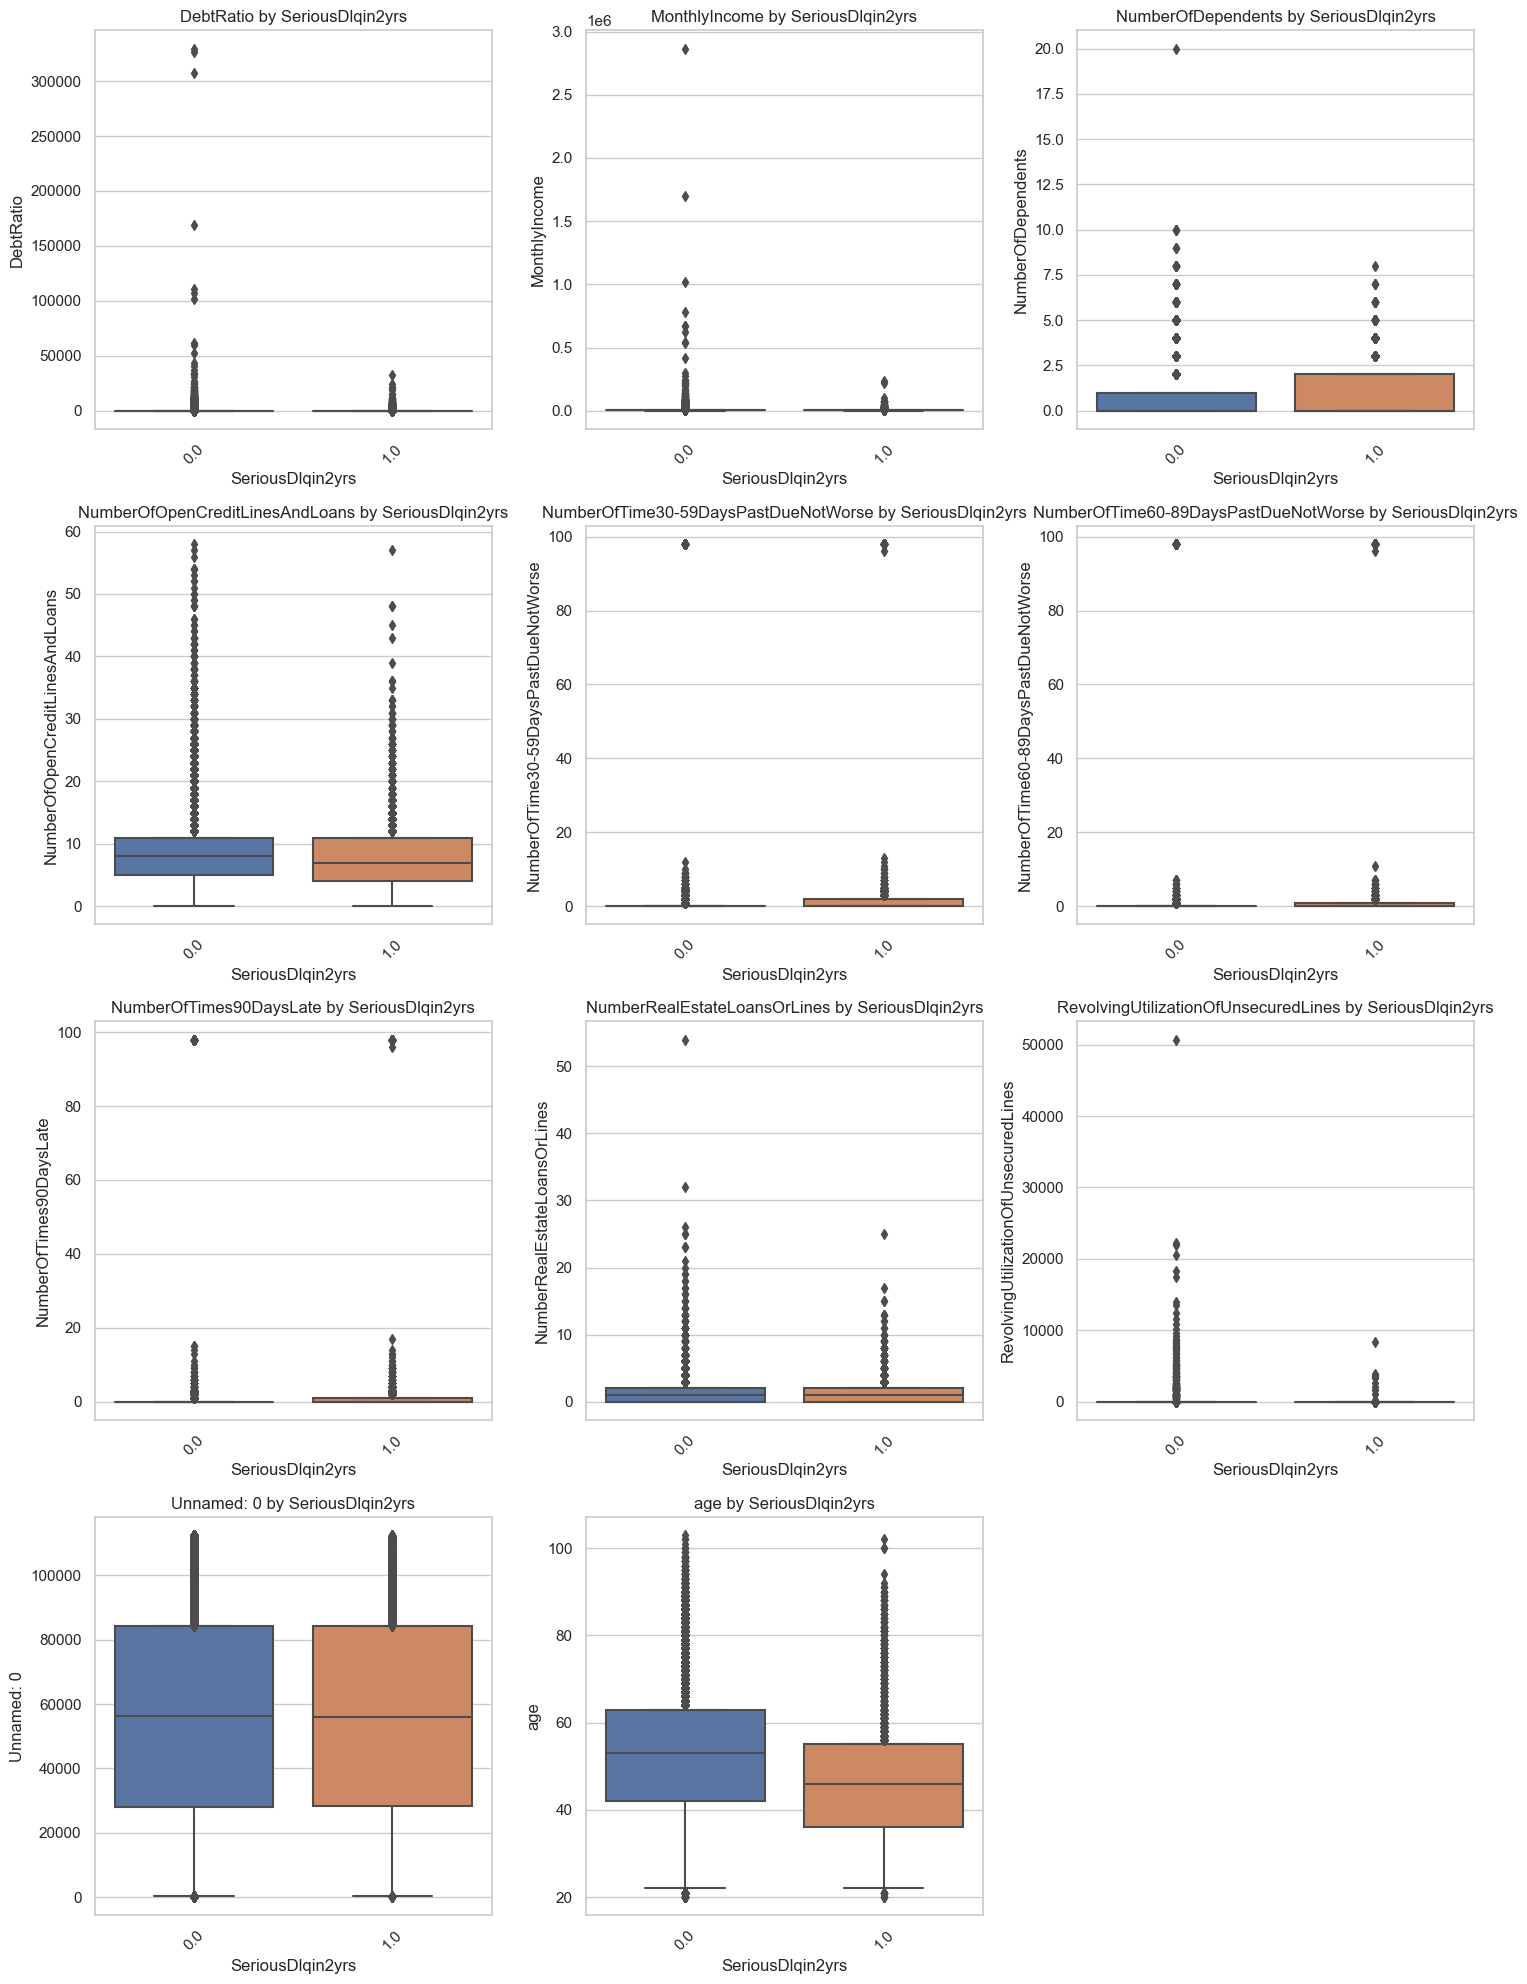

In [277]:
variables_to_plot = data_train.columns.difference(['SeriousDlqin2yrs'])

#subplot grid
n_vars = len(variables_to_plot)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

for i, variable in enumerate(variables_to_plot):
    sns.boxplot(x='SeriousDlqin2yrs', y=variable,whis=[0.25, 0.75], data=data_train, ax=axes[i])
    axes[i].set_title(f'{variable} by SeriousDlqin2yrs')
    axes[i].tick_params(axis='x', labelrotation=45)  # Ruota le etichette dell'asse x per evitare sovrapposizioni


for ax in axes[len(variables_to_plot):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


The presence of significant outliers across several key financial indicators, such as debt ratio and credit utilization, which correlate with serious delinquency, suggests that retaining outliers may provide crucial insights into financial behavior and risk assessment. For this reason, and to avoid deleting a large portion of the data, we decided to only delete outliers above the 99th and below the 1st percentile.

In [278]:
def remove_outliers_by_percentiles(df, low_perc=0.01, high_perc=0.99):
    def find_outliers_percentiles(column):
        lower_threshold = df[column].quantile(low_perc)
        upper_threshold = df[column].quantile(high_perc)
        return df[(df[column] < lower_threshold) | (df[column] > upper_threshold)].index

    outlier_indices = set()
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

    for column in numeric_columns:
        column_outliers = find_outliers_percentiles(column)
        outlier_indices.update(column_outliers)

    outlier_indices = list(outlier_indices)
    df_cleaned = df.drop(outlier_indices)

    return df_cleaned

data_train2 = remove_outliers_by_percentiles(data_train1)
print("original dimension:", data_train1.shape)
print("new dimension:", data_train2.shape)
assert not data_train2.isna().any().any()

original dimension: (112499, 11)
new dimension: (104283, 11)


# Feature Engineering

In [279]:
# We add an income for dependent column
data_train2['income_dependent'] = data_train2['MonthlyIncome'] / (data_train2['NumberOfDependents'] + 1)

In [280]:
# We add a delinquency ratio column: 

data_train2['DelinquencyRatio'] = (data_train2['NumberOfTime30-59DaysPastDueNotWorse'] + data_train2['NumberOfTimes90DaysLate'] + data_train2['NumberOfTime60-89DaysPastDueNotWorse']) / (data_train2['NumberOfOpenCreditLinesAndLoans'] + 1)

In [281]:
poly = PolynomialFeatures(degree=2, include_bias=False)

features_to_poly = ['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents']

# fit transform the data
data_poly = poly.fit_transform(data_train2[features_to_poly].copy())

# create a new dataframe with the polynomial features
data_poly = pd.DataFrame(data_poly, columns=poly.get_feature_names_out(features_to_poly))

# merge the data with the non-polynomial features
data_non_poly = data_train2.drop(columns=features_to_poly)

data_poly[data_non_poly.columns] = data_non_poly.values
data_poly.head()


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,...,NumberOfTimes90DaysLate NumberOfDependents,NumberRealEstateLoansOrLines^2,NumberRealEstateLoansOrLines NumberOfTime60-89DaysPastDueNotWorse,NumberRealEstateLoansOrLines NumberOfDependents,NumberOfTime60-89DaysPastDueNotWorse^2,NumberOfTime60-89DaysPastDueNotWorse NumberOfDependents,NumberOfDependents^2,SeriousDlqin2yrs,income_dependent,DelinquencyRatio
0,0.034949,59.0,0.0,0.004933,7959.688894,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7959.688894,0.000000
1,0.155308,47.0,0.0,881.000000,6328.079574,6.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,6328.079574,0.000000
2,0.165166,62.0,1.0,0.020327,2851.722407,8.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2851.722407,0.111111
3,0.010886,61.0,0.0,0.642979,1115.657341,6.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1115.657341,0.000000
4,0.000717,49.0,0.0,3603.000000,6328.079574,15.0,0.0,3.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,6328.079574,0.000000


# Feature Selection

In [282]:
data_poly_deepcopy = deepcopy(data_poly)
data_poly_FS = data_poly.drop(columns=['SeriousDlqin2yrs'])

# Split the data into training and test sets, preserving the indices
X_train_FS, X_test_FS, y_train, y_test = train_test_split(data_poly_FS, data_poly['SeriousDlqin2yrs'], test_size=0.2, random_state=42)

X_train_FS.columns

Index(['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'RevolvingUtilizationOfUnsecuredLines^2',
       'RevolvingUtilizationOfUnsecuredLines age',
       'RevolvingUtilizationOfUnsecuredLines NumberOfTime30-59DaysPastDueNotWorse',
       'RevolvingUtilizationOfUnsecuredLines DebtRatio',
       'RevolvingUtilizationOfUnsecuredLines MonthlyIncome',
       'RevolvingUtilizationOfUnsecuredLines NumberOfOpenCreditLinesAndLoans',
       'RevolvingUtilizationOfUnsecuredLines NumberOfTimes90DaysLate',
       'RevolvingUtilizationOfUnsecuredLines NumberRealEstateLoansOrLines',
       'RevolvingUtilizationOfUnsecuredLines NumberOfTime60-89DaysPastDueNotWorse',
       'RevolvingUtilizationOfUnsecuredLines NumberOfDependents', 'age^2',
       'age 

In [283]:
# Make 'SeriousDlqin2yrs' into a categorical variable
y = y_train.astype('category')

In [325]:
# implement RFECV feature selection with GradientBoostingClassifier

# create the model
model = XGBClassifier(n_jobs=-1, random_state = 42, n_estimators=120)

# create the RFECV object
rfecv_xgb = RFECV(estimator=model, step=1, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

# fit the RFECV object
rfecv_xgb.fit(X_train_FS, y)

print(f'Mean test score: ', rfecv_xgb.cv_results_['mean_test_score'])
print(f'Standard deviation: ', rfecv_xgb.cv_results_['std_test_score'])

# print the results
print("Optimal number of features : %d" % rfecv_xgb.n_features_)
print("Best features : ", X_train_FS.columns[rfecv_xgb.support_])

Fitting estimator with 67 features.
Fitting estimator with 67 features.
Fitting estimator with 67 features.
Fitting estimator with 67 features.
Fitting estimator with 67 features.
Fitting estimator with 66 features.
Fitting estimator with 66 features.
Fitting estimator with 66 features.
Fitting estimator with 66 features.
Fitting estimator with 66 features.
Fitting estimator with 65 features.
Fitting estimator with 65 features.
Fitting estimator with 65 features.
Fitting estimator with 65 features.
Fitting estimator with 65 features.
Fitting estimator with 64 features.
Fitting estimator with 64 features.
Fitting estimator with 64 features.
Fitting estimator with 64 features.
Fitting estimator with 64 features.
Fitting estimator with 63 features.
Fitting estimator with 63 features.
Fitting estimator with 63 features.
Fitting estimator with 63 features.
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 62 features.
Fitting estimator with 62 fe

In [326]:
# implement RFECV feature selection with RandomForestClassifier

# create the model
model = RandomForestClassifier(n_estimators=50, random_state = 42)

# create the RFECV object
rfecv_rf = RFECV(estimator=model, step=1, cv=3, scoring='roc_auc', n_jobs=-1, verbose=2)

# fit the RFECV object
rfecv_rf.fit(X_train_FS, y)

print(f'Mean score: ', rfecv_rf.cv_results_['mean_test_score'])
print(f'Standard deviation: ', rfecv_rf.cv_results_['std_test_score'])

# print the results
print("Optimal number of features : %d" % rfecv_rf.n_features_)
print("Best features : ", X_train_FS.columns[rfecv_rf.support_])

Fitting estimator with 67 features.
Fitting estimator with 67 features.
Fitting estimator with 67 features.
Fitting estimator with 66 features.
Fitting estimator with 66 features.
Fitting estimator with 66 features.
Fitting estimator with 65 features.
Fitting estimator with 65 features.
Fitting estimator with 65 features.
Fitting estimator with 64 features.
Fitting estimator with 64 features.
Fitting estimator with 64 features.
Fitting estimator with 63 features.
Fitting estimator with 63 features.
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 62 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 61 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 60 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 59 features.
Fitting estimator with 59 features.
Fitting estimator with 58 fe

In [381]:
# create a dataframe with the results
results = pd.DataFrame({
    'Feature': X_train_FS.columns,
    'GradientBoosting': rfecv_xgb.support_,
    'RandomForest': rfecv_rf.support_
})

# add a column with the sum of the two columns
results['Sum'] = results['GradientBoosting'] & results['RandomForest']

# order the dataframe by the sum of the two columns
results = results.sort_values(by='Sum', ascending=False)

# remove print limit
pd.set_option('display.max_rows', None)
print(results[['Feature', 'Sum']])

                                              Feature    Sum
0                RevolvingUtilizationOfUnsecuredLines   True
12  RevolvingUtilizationOfUnsecuredLines NumberOfT...   True
46              MonthlyIncome NumberOfTimes90DaysLate   True
42     DebtRatio NumberOfTime60-89DaysPastDueNotWorse   True
41             DebtRatio NumberRealEstateLoansOrLines   True
40                  DebtRatio NumberOfTimes90DaysLate   True
39          DebtRatio NumberOfOpenCreditLinesAndLoans   True
38                            DebtRatio MonthlyIncome   True
22                                      age DebtRatio   True
18  RevolvingUtilizationOfUnsecuredLines NumberOfT...   True
15  RevolvingUtilizationOfUnsecuredLines NumberOfO...   True
66                                   DelinquencyRatio   True
3                                           DebtRatio   True
11           RevolvingUtilizationOfUnsecuredLines age  False
53  NumberOfOpenCreditLinesAndLoans NumberOfTime60...  False
43                      

In [382]:
# chosen features
chosen_features = results[results['Sum'] == True]['Feature'].values

# original features
original_features = ['RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents']

# original features not selected
original_features_not_selected = [feature for feature in original_features if feature not in chosen_features]

# original features not considered
original_features_not_considered = []
for original_feature in original_features_not_selected:
    considered = False
    for chosen_feature in chosen_features:
        if original_feature in chosen_feature:
            considered = True
    if not considered:
        original_features_not_considered.append(original_feature)


print(f'Original features not selected: {original_features_not_selected}')
print(f'Original features not considered: {original_features_not_considered}')

Original features not selected: ['age', 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Original features not considered: ['NumberOfDependents']


In [383]:
# features to keep
x_features_to_keep = list(chosen_features) + original_features_not_considered 

print(f'{len(x_features_to_keep)} features to keep: \n{x_features_to_keep}')

14 features to keep: 
['RevolvingUtilizationOfUnsecuredLines', 'RevolvingUtilizationOfUnsecuredLines NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome NumberOfTimes90DaysLate', 'DebtRatio NumberOfTime60-89DaysPastDueNotWorse', 'DebtRatio NumberRealEstateLoansOrLines', 'DebtRatio NumberOfTimes90DaysLate', 'DebtRatio NumberOfOpenCreditLinesAndLoans', 'DebtRatio MonthlyIncome', 'age DebtRatio', 'RevolvingUtilizationOfUnsecuredLines NumberOfTime60-89DaysPastDueNotWorse', 'RevolvingUtilizationOfUnsecuredLines NumberOfOpenCreditLinesAndLoans', 'DelinquencyRatio', 'DebtRatio', 'NumberOfDependents']


In [384]:
X_train2=X_train_FS[x_features_to_keep]
y_train2= y_train.astype('float64')


X_test2= X_test_FS[x_features_to_keep]
y_test2= y_test.astype('float64')

print(X_train2.columns)

Index(['RevolvingUtilizationOfUnsecuredLines',
       'RevolvingUtilizationOfUnsecuredLines NumberOfTime30-59DaysPastDueNotWorse',
       'MonthlyIncome NumberOfTimes90DaysLate',
       'DebtRatio NumberOfTime60-89DaysPastDueNotWorse',
       'DebtRatio NumberRealEstateLoansOrLines',
       'DebtRatio NumberOfTimes90DaysLate',
       'DebtRatio NumberOfOpenCreditLinesAndLoans', 'DebtRatio MonthlyIncome',
       'age DebtRatio',
       'RevolvingUtilizationOfUnsecuredLines NumberOfTime60-89DaysPastDueNotWorse',
       'RevolvingUtilizationOfUnsecuredLines NumberOfOpenCreditLinesAndLoans',
       'DelinquencyRatio', 'DebtRatio', 'NumberOfDependents'],
      dtype='object')


# Multicollinearity



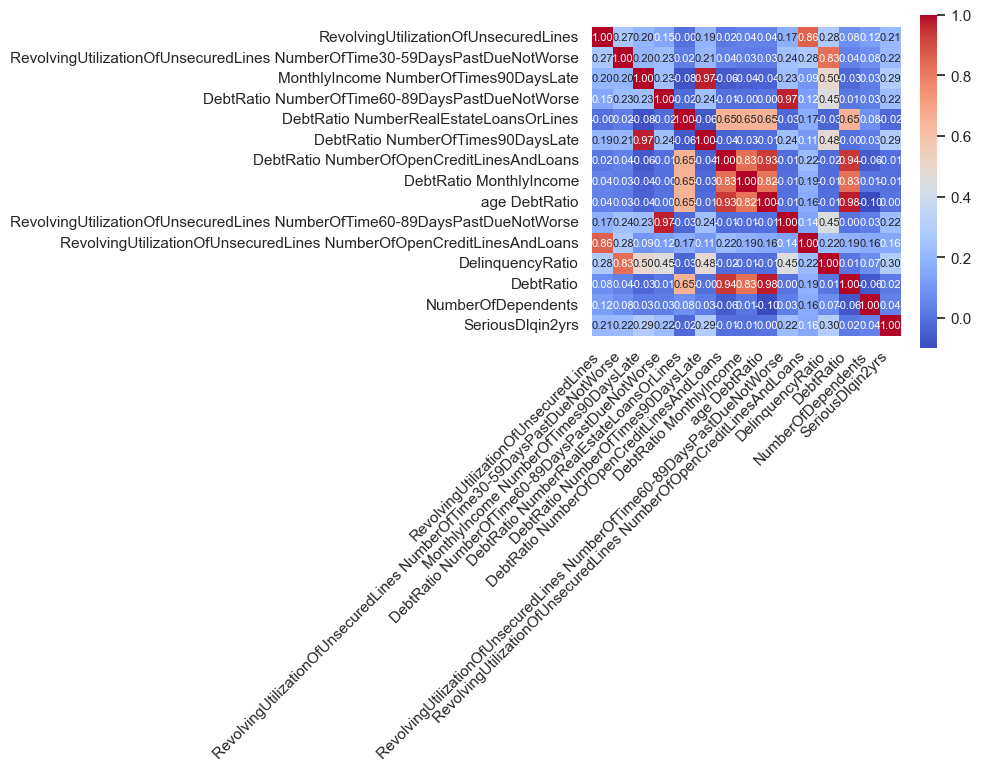

In [385]:
#Unite training dataset
X_train2_copy=deepcopy(X_train2)
X_train2_copy['SeriousDlqin2yrs'] = y_train2
X_train2_total= X_train2_copy
# Calculate the correlation matrix
corr_matrix = X_train2_total.corr(method = "spearman") #spiegare metodoo

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, annot_kws={"size": 8})

# Adjust layout to make room for the rotated x-axis labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

In [386]:
# Calculate the absolute correlation matrix
abs_corr_matrix = np.abs(corr_matrix.values)

# Find indices where correlation is between 0.4 and 0.7
indices_0_4_to_0_7 = np.where((0.4 <= abs_corr_matrix) & (abs_corr_matrix < 0.7))

# Set diagonal elements to zero
np.fill_diagonal(abs_corr_matrix, 0)

# Find indices where correlation is above 0.7
indices_above_0_7 = np.where(abs_corr_matrix > 0.7)

# Initialize a set to store seen pairs
seen_pairs = set()

# Get feature pairs with correlation between 0.4 and 0.7 (excluding specular counterparts)
correlation_0_4_to_0_7_filtered = [(corr_matrix.index[i], corr_matrix.columns[j]) for i, j in zip(*indices_0_4_to_0_7) if (corr_matrix.columns[j], corr_matrix.index[i]) not in seen_pairs and not seen_pairs.add((corr_matrix.index[i], corr_matrix.columns[j]))]

# Get feature pairs with correlation above 0.7 (excluding diagonal elements and specular counterparts)
correlation_above_0_7_filtered = [(corr_matrix.index[i], corr_matrix.columns[j]) for i, j in zip(*indices_above_0_7) if (corr_matrix.columns[j], corr_matrix.index[i]) not in seen_pairs and not seen_pairs.add((corr_matrix.index[i], corr_matrix.columns[j]))]

# Print the lists of correlated feature pairs
print("Feature pairs with correlation between 0.4 and 0.7:")
for pair in correlation_0_4_to_0_7_filtered:
    print(pair)

print("\nFeature pairs with correlation above 0.7 (excluding diagonal elements and specular counterparts):")
for pair in correlation_above_0_7_filtered:
    print(pair)


Feature pairs with correlation between 0.4 and 0.7:
('MonthlyIncome NumberOfTimes90DaysLate', 'DelinquencyRatio')
('DebtRatio NumberOfTime60-89DaysPastDueNotWorse', 'DelinquencyRatio')
('DebtRatio NumberRealEstateLoansOrLines', 'DebtRatio NumberOfOpenCreditLinesAndLoans')
('DebtRatio NumberRealEstateLoansOrLines', 'DebtRatio MonthlyIncome')
('DebtRatio NumberRealEstateLoansOrLines', 'age DebtRatio')
('DebtRatio NumberRealEstateLoansOrLines', 'DebtRatio')
('DebtRatio NumberOfTimes90DaysLate', 'DelinquencyRatio')
('RevolvingUtilizationOfUnsecuredLines NumberOfTime60-89DaysPastDueNotWorse', 'DelinquencyRatio')

Feature pairs with correlation above 0.7 (excluding diagonal elements and specular counterparts):
('RevolvingUtilizationOfUnsecuredLines', 'RevolvingUtilizationOfUnsecuredLines NumberOfOpenCreditLinesAndLoans')
('RevolvingUtilizationOfUnsecuredLines NumberOfTime30-59DaysPastDueNotWorse', 'DelinquencyRatio')
('MonthlyIncome NumberOfTimes90DaysLate', 'DebtRatio NumberOfTimes90DaysLat

For couples of variables with modest correlation, between 0.4 and 0.7, we analyse the scatter plots, in order to better understand whether there is any visible sign of collinearity.

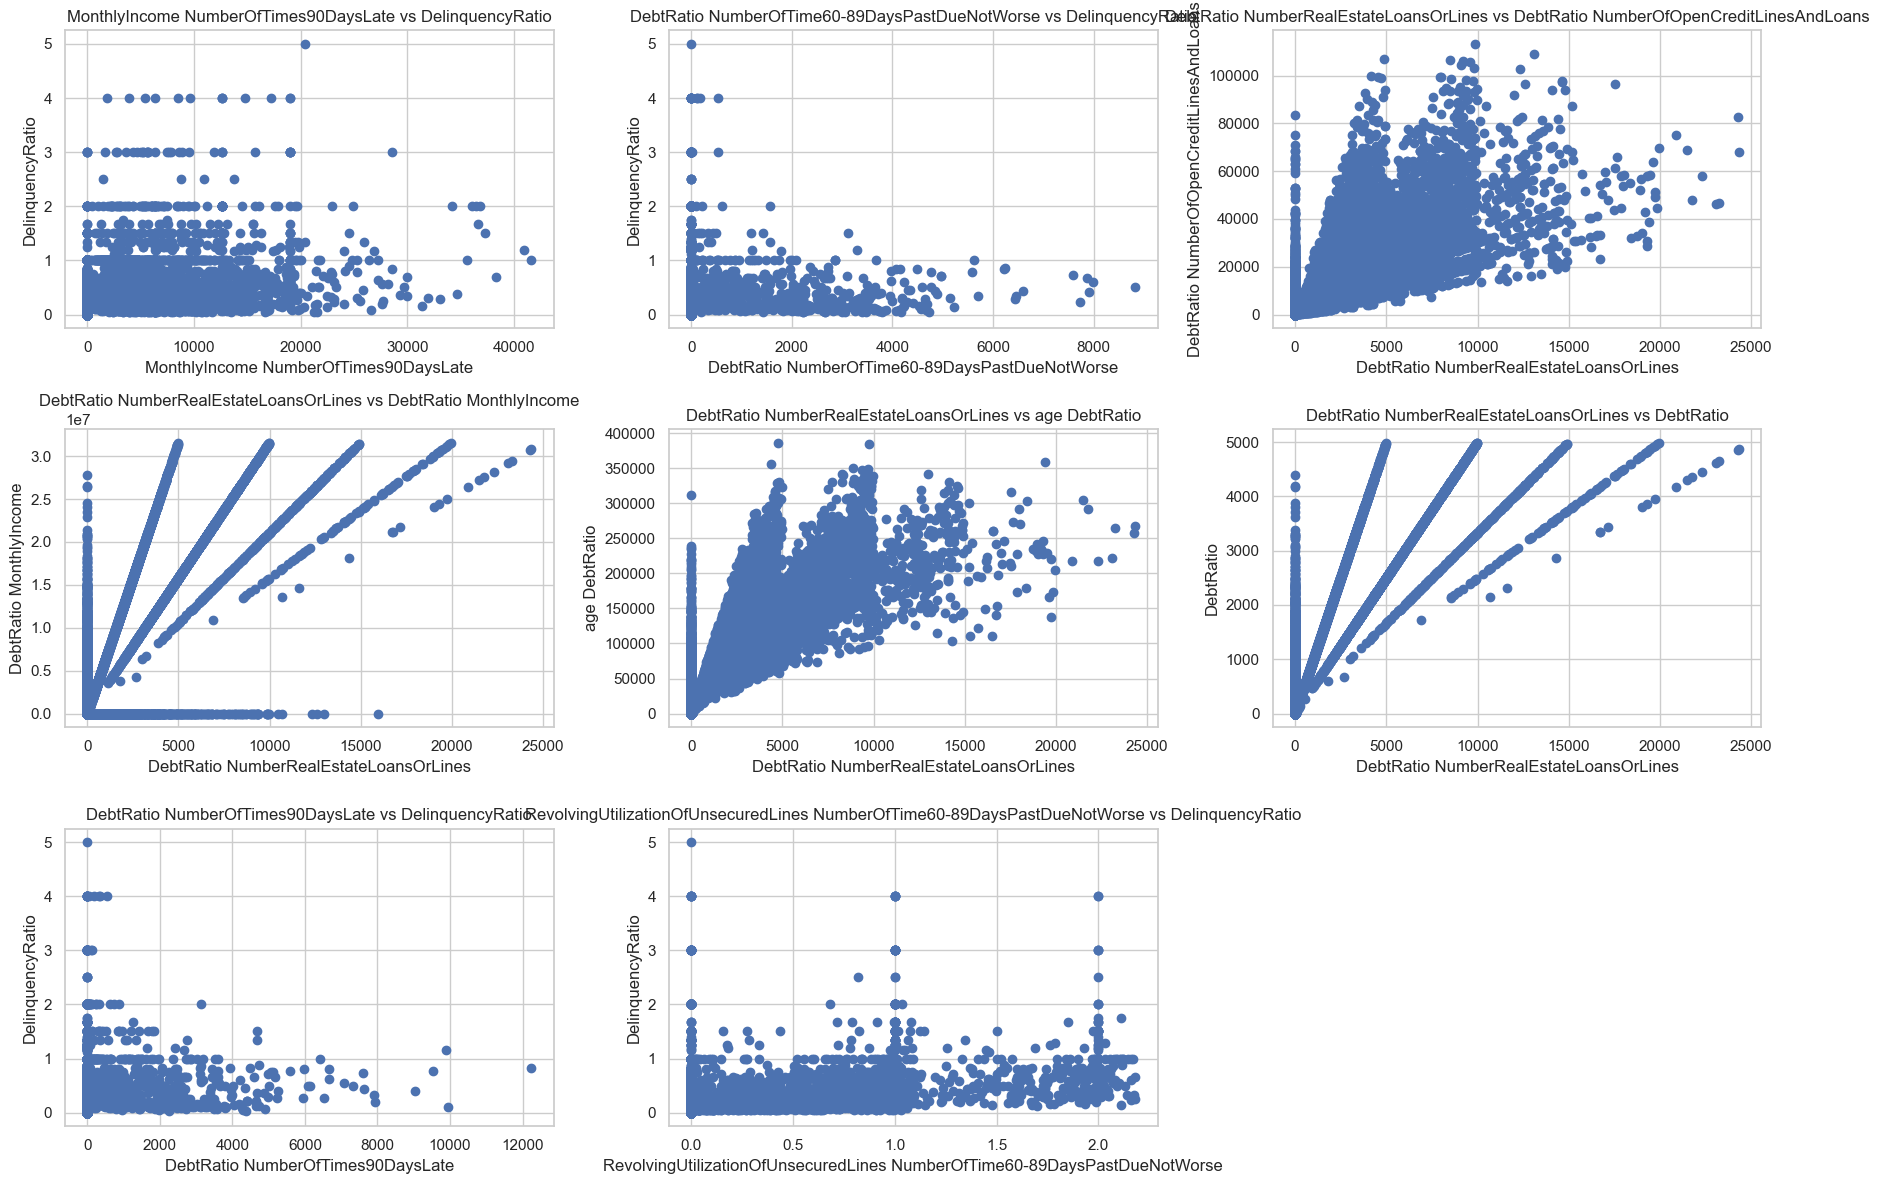

In [387]:
# Calculate the number of rows and columns for subplots
num_pairs = len(correlation_0_4_to_0_7_filtered)
num_cols = 3  # Adjust the number of columns as needed
num_rows = (num_pairs + num_cols - 1) // num_cols

# Set the size of the figure
plt.figure(figsize=(num_cols * 6, num_rows * 4))

# Plot scatterplots for each pair of features in the list
for i, pair in enumerate(correlation_0_4_to_0_7_filtered, start=1):
    feature1, feature2 = pair
    plt.subplot(num_rows, num_cols, i)
    plt.scatter(X_train2_total[feature1], X_train2_total[feature2])
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f'{feature1} vs {feature2}')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


 The DebtRatio-NumberRealEstateLoansOrLines wrt DebtRatio-NumberOfOpendCreditLinesandLoans, DebtRatio-MontlhyIncome, age-DebtRatio and DebtRatio graphs clearly show multicollinearity. However, other graphs don't indicate strong linear correlations among the variables. This suggests that, aside from the highlighted cases, the variables are not strongly interrelated to the extent that would lead to notable multicollinearity issues in a predictive model

 For festures that have a correlation above 0.7, instead we only keep the most relevant one for each pair, as we consider them to have high collinearity. 
 To do so, first we rank all selected features based on their relevance, according to the results obtained during feature selection

In [389]:

# Merge the rankings from both classifiers by taking the average
merged_feature_ranking = (rfecv_rf.ranking_ + rfecv_xgb.ranking_) / 2

# Create a dictionary to map feature names to their merged rankings
merged_feature_ranking_dict = dict(zip(X_train_FS.columns, merged_feature_ranking))

# Sort the dictionary by ranking
sorted_features = sorted(merged_feature_ranking_dict.items(), key=lambda item: item[1])

# Assign unique ranks based on position in the sorted list
unique_ranking_dict = {feature: rank + 1 for rank, (feature, _) in enumerate(sorted_features)}

# Print the uniquely ranked features to visualize the results
print("Unique Feature Rankings:")
for feature, rank in unique_ranking_dict.items():
    print(f"{feature}: {rank}")


Unique Feature Rankings:
RevolvingUtilizationOfUnsecuredLines: 1
DebtRatio: 2
RevolvingUtilizationOfUnsecuredLines NumberOfTime30-59DaysPastDueNotWorse: 3
RevolvingUtilizationOfUnsecuredLines NumberOfOpenCreditLinesAndLoans: 4
RevolvingUtilizationOfUnsecuredLines NumberOfTime60-89DaysPastDueNotWorse: 5
age DebtRatio: 6
DebtRatio MonthlyIncome: 7
DebtRatio NumberOfOpenCreditLinesAndLoans: 8
DebtRatio NumberOfTimes90DaysLate: 9
DebtRatio NumberRealEstateLoansOrLines: 10
DebtRatio NumberOfTime60-89DaysPastDueNotWorse: 11
MonthlyIncome NumberOfTimes90DaysLate: 12
DelinquencyRatio: 13
NumberOfOpenCreditLinesAndLoans NumberRealEstateLoansOrLines: 14
MonthlyIncome NumberOfTime60-89DaysPastDueNotWorse: 15
RevolvingUtilizationOfUnsecuredLines NumberOfTimes90DaysLate: 16
age: 17
MonthlyIncome: 18
age NumberOfOpenCreditLinesAndLoans: 19
income_dependent: 20
NumberOfOpenCreditLinesAndLoans NumberOfTimes90DaysLate: 21
RevolvingUtilizationOfUnsecuredLines NumberRealEstateLoansOrLines: 22
age NumberO

Then, for each pair in correlation_above_0.7_filtered we only keep the most relevant variable, making sure that we don't keep any combination of highly correlated features.

In [390]:
# Step 1: Add features selected form scatter plots to correlation_above_0_7_filtered
correlated_features = [("DebtRatio", "DebtRatio NumberRealEstateLoansOrLines"), 
                                      ("DebtRatio NumberOfOpendCreditLinesandLoans", "DebtRatio NumberRealEstateLoansOrLines"), 
                                      ("DebtRatio MontlhyIncome", "DebtRatio NumberRealEstateLoansOrLines"),
                                      ("age DebtRatio", "DebtRatio NumberRealEstateLoansOrLines")]
for x in correlated_features:
    correlation_above_0_7_filtered.append(x)

# Step 2: Create a list of all single elements in correlation_above_0_7_filtered with no repetition
features_to_check = list(set().union(*correlation_above_0_7_filtered))

# Step 3: Rank the features based on their relevance
feature_ranking = {feature: rank for rank, feature in enumerate(sorted(features_to_check, key=lambda x: merged_feature_ranking_dict.get(x, float('inf'))))}

# Step 4: Create a matrix with all the features in features_to_check as rows and columns
num_features = len(features_to_check)
feature_matrix = np.zeros((num_features, num_features))

# Step 5: Set each entry to 1 if the coordinates form a pair of correlation_above_0_7_filtered
for feature1, feature2 in correlation_above_0_7_filtered:
    rank_feature1 = feature_ranking[feature1]
    rank_feature2 = feature_ranking[feature2]
    feature_matrix[rank_feature1, rank_feature2] = 1
    feature_matrix[rank_feature2, rank_feature1] = 1  # Symmetric matrix

# Step 6: Find features to drop
features_to_drop = []
for i in range(num_features):
    if np.any(feature_matrix[i, i+1:]):  # Check below the diagonal
        features_to_drop.append(list(feature_ranking.keys())[i])
        feature_matrix[i, :] = 0
        feature_matrix[:, i] = 0

# Print features to drop
print("Features to drop:")
print(features_to_drop)
print(len(features_to_drop))

Features to drop:
['RevolvingUtilizationOfUnsecuredLines NumberOfTime60-89DaysPastDueNotWorse', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio MonthlyIncome', 'age DebtRatio', 'RevolvingUtilizationOfUnsecuredLines NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio NumberOfTimes90DaysLate', 'DebtRatio NumberOfOpenCreditLinesAndLoans', 'DebtRatio NumberRealEstateLoansOrLines']
8


In [404]:
# Drop columns in X_train2 and X_test2 that are in features_to_drop
X_train2_filtered = X_train2.drop(columns=features_to_drop)
X_test2_filtered = X_test2.drop(columns=features_to_drop)
# Print the shape of the filtered dataset
print("Shape of X_train2:", X_train2.shape)
print("Shape of X_train2_filtered:", X_train2_filtered.shape)
print("Shape of X_test2_filtered:", X_test2_filtered.shape)

Shape of X_train2: (83426, 14)
Shape of X_train2_filtered: (83426, 6)
Shape of X_test2_filtered: (20857, 6)


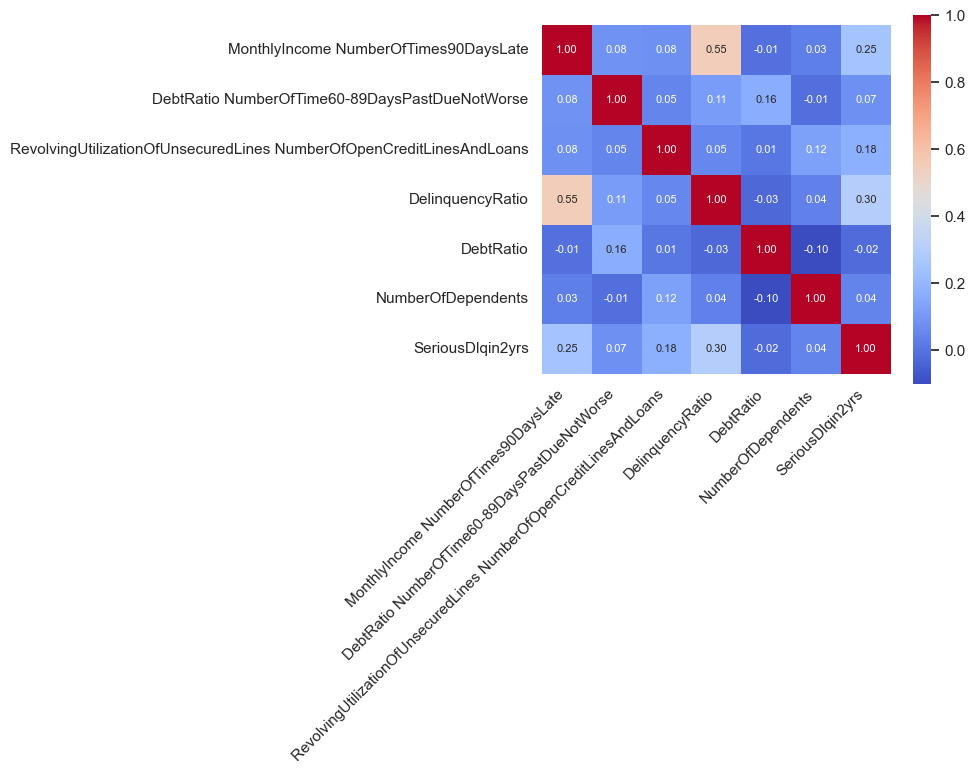

In [405]:
# Calculate the correlation matrix
X_train2_filtered_total = deepcopy(X_train2_filtered)
X_train2_filtered_total['SeriousDlqin2yrs'] = y_train2
corr_matrix_modified = X_train2_filtered_total.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Generate a heatmap
sns.heatmap(corr_matrix_modified, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, annot_kws={"size": 8})

# Adjust layout to make room for the rotated x-axis labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()


# Scaling

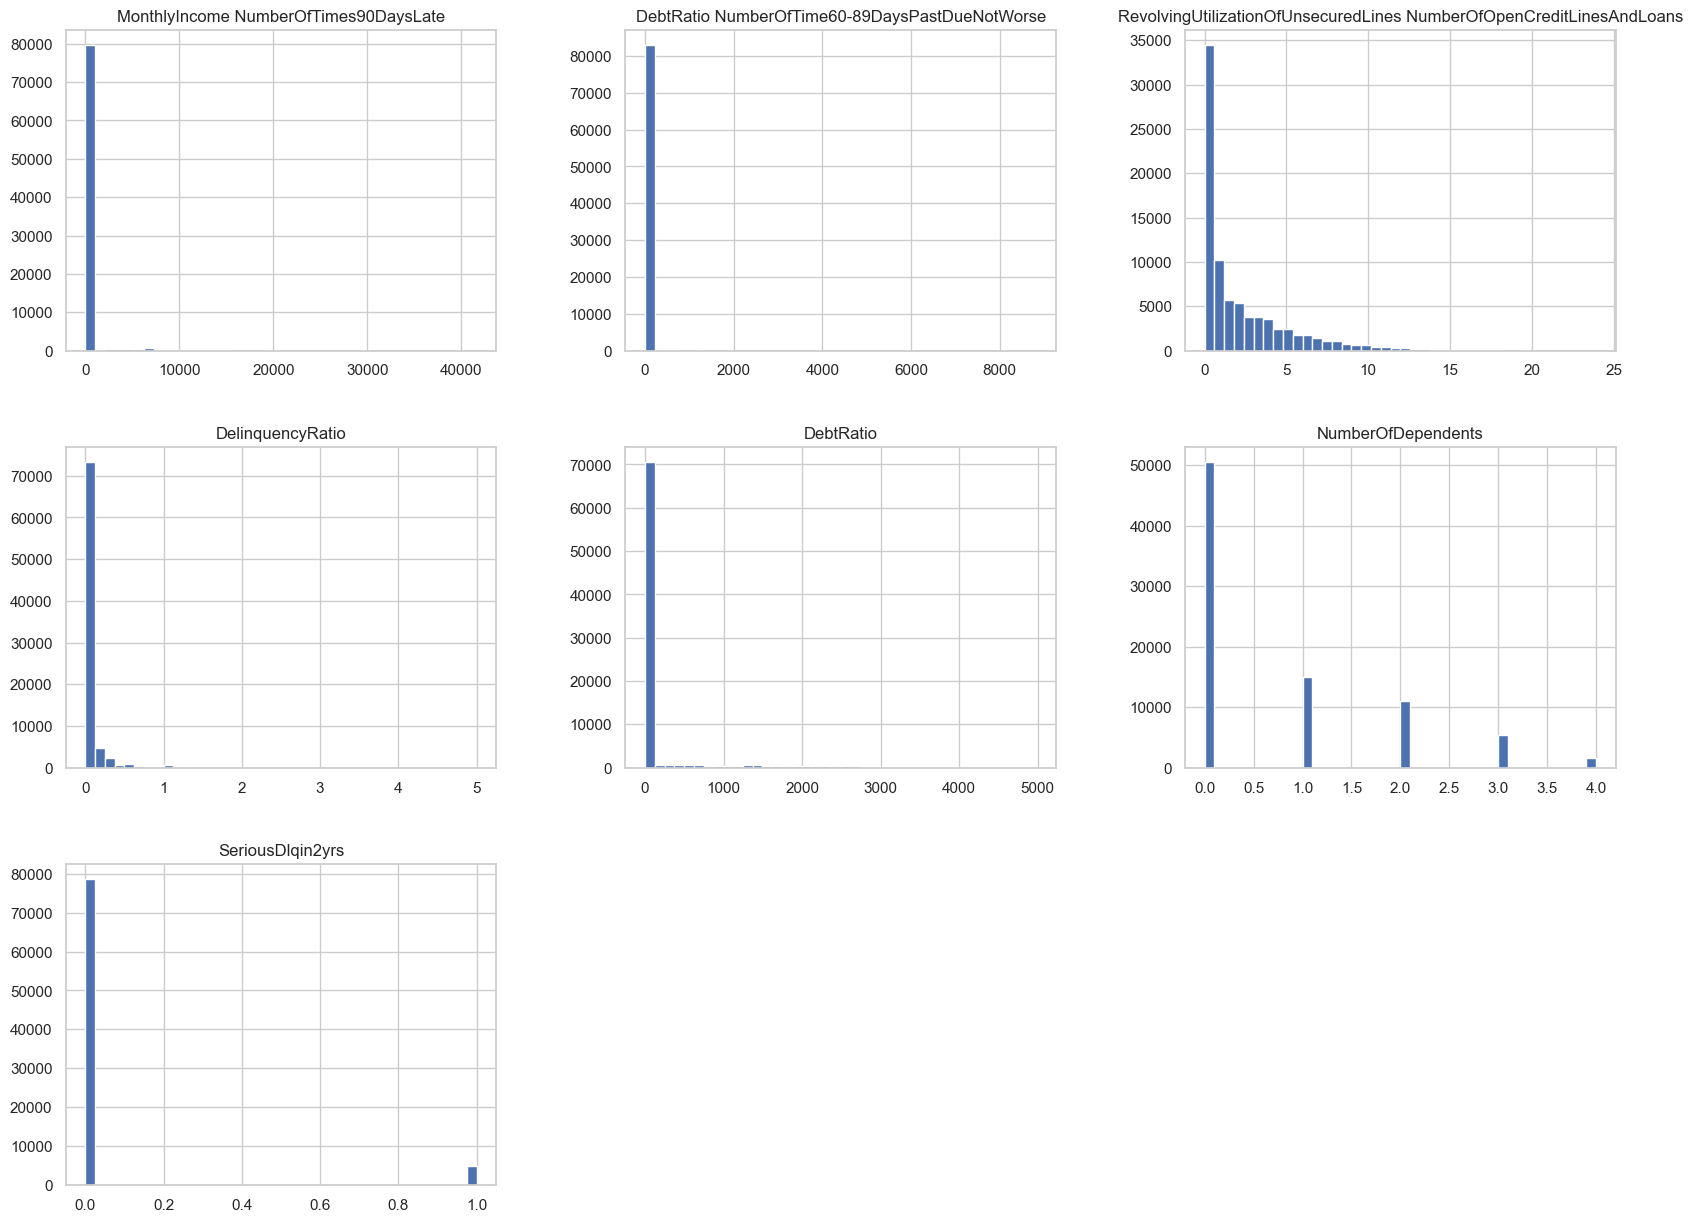

In [406]:
#Plot the distribution of all variables now
X_train2_filtered_total.hist(bins=40, figsize=(20,15))
plt.show()

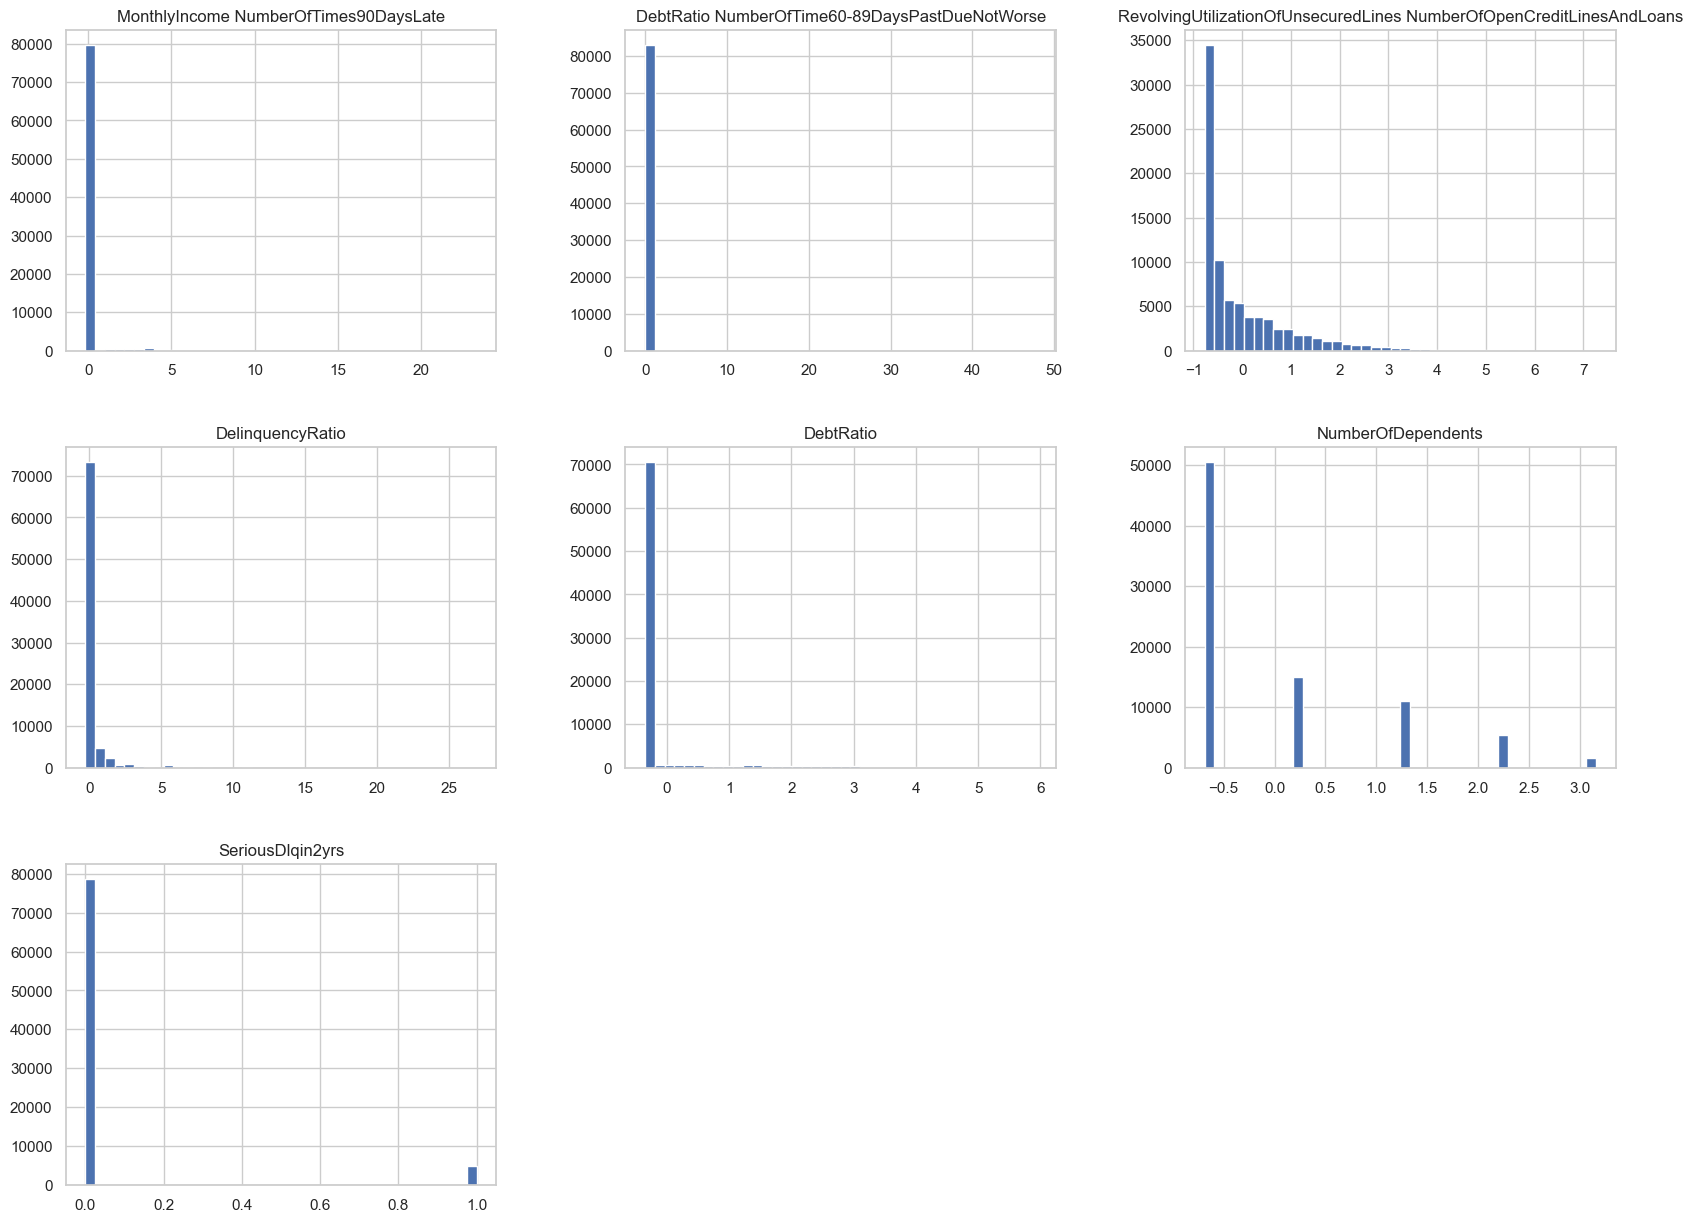

In [394]:
#Given data are of different size, we want to apply  scaling,
#particularly a standardization.

# Perform scaling on the features separately for the training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train2_filtered)
data_train3 = pd.DataFrame(X_train_scaled, columns=X_train2_filtered.columns, index=X_train2_filtered.index)

# Perform scaling on the features separately for the test set
X_test_scaled = scaler.transform(X_test2_filtered)
data_test3 = pd.DataFrame(X_test_scaled, columns=X_test2_filtered.columns, index=X_test2_filtered.index)

# Add the target column back to the train set
data_train3['SeriousDlqin2yrs'] = y_train2.values
# Add the target column back to the test set
data_test3['SeriousDlqin2yrs'] = y_test2.values

# Plot histograms of the scaled features without log
data_train3.hist(bins=40, figsize=(20,15))
plt.show()


We choose standardization instead of other methods for the following reasons:


*   the variables had really different scales
*   the standardization is less influenced by outliers wrt min-max scaling
*   by giving a standardized scale, it will be easier to compare the coefficients later on in the model





In [407]:
#FINAL DATASET FOR MODEL ANALYSIS

X_train_final = X_train_scaled
y_train_final = y_train2
X_test_final = X_test_scaled
y_test_final = y_test2
data_train_final = data_train3
data_test_final = data_test3

# Model analysis 

To find the most appropriate algorithm for our problem, we tune 4 different type of classifiers, using GridSearchCV:
- Logistic Regression
- Bagging, using a Decision Tree Classifier
- XGBoost
- HistGradientBoost

We start with a coarse grid search using a wide range of values for each hyperparameter.
For Grid Search, we use roc_auc as a scoring metrics instead of accuracy, as it is more representative for performance over unbalanced datasets. Moreover, we take advantage of balancing parameters of the individual algorithms, since we are dealing with a singificantly unbalanced dataset.

**Logistic Regression**

In [413]:
#LOGISTIC REGRESSION

param_grid = [
  {'C': np.logspace(-4, 4, 5), 'penalty':  ['l1', 'l2'], 'max_iter': np.linspace(100, 1000, 4, dtype=int), 'solver': ['saga'], 'class_weight': ['balanced']},
]
estimator = LogisticRegression()
grid_search = GridSearchCV(estimator, param_grid, cv=5, scoring= 'roc_auc')

# Fit grid search to the data
grid_search.fit(X_train_final, y_train_final)

# Print best parameters
print("Best Parameters: ", grid_search.best_params_)

# Evaluate the best model on test set
best_model_lr = grid_search.best_estimator_
test_preds_lr = best_model_lr.predict(X_test_final)

Best Parameters:  {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}


In [414]:
#Print performance measures
print(f'Accuracy: {accuracy_score(y_test_final, test_preds_lr)}')
print(f'ROC AUC: {roc_auc_score(y_test_final, test_preds_lr)}')
print(f'F1 score: {f1_score(y_test_final, test_preds_lr)}')
print(f'Precision: {precision_score(y_test_final, test_preds_lr)}')
print(f'Recall: {recall_score(y_test_final, test_preds_lr)}')

Accuracy: 0.8169439516709018
ROC AUC: 0.7485947914911844
F1 score: 0.29557195571955724
Precision: 0.18949609652235627
Recall: 0.6714165968147527


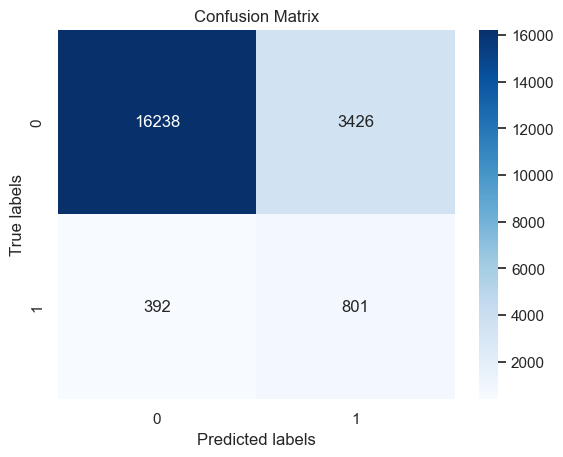

In [415]:
#PLOT CONFUSION MATRIX

# Calculate confusion matrix
cm = confusion_matrix(y_test_final, test_preds_lr)

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

**Bagging with Decision Tree Classifier**

In [409]:
# Define the base classifier (Decision Tree)
base_classifier = DecisionTreeClassifier()

# Define the Bagging classifier
bagging_classifier = BaggingClassifier(base_estimator=base_classifier, random_state=42)

# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [10, 100],
    'max_samples': [0.5, 1.0],
    'max_features': [0.5, 1.0],
    'base_estimator__max_depth': [None, 10, 20]
}

# Perform GridSearchCV to find the best combination of hyperparameters
grid_search = GridSearchCV(estimator=bagging_classifier, param_grid=param_grid, cv=5, scoring='roc_auc', verbose=1)
grid_search.fit(X_train_final, y_train_final)

# Print the best parameters found
print("Best parameters:", grid_search.best_params_)

# Get the best Bagging classifier
best_bagging_classifier = grid_search.best_estimator_

# Make predictions on the test set
test_preds_bagging = best_bagging_classifier.predict(X_test_final)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'base_estimator__max_depth': 10, 'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 100}


In [410]:
#Print performance measures
print(f'Accuracy: {accuracy_score(y_test_final, test_preds_bagging)}')
print(f'ROC AUC: {roc_auc_score(y_test_final, test_preds_bagging)}')
print(f'F1 score: {f1_score(y_test_final, test_preds_bagging)}')
print(f'Precision: {precision_score(y_test_final, test_preds_bagging)}')
print(f'Recall: {recall_score(y_test_final, test_preds_bagging)}')

Accuracy: 0.9433283789614998
ROC AUC: 0.5105154909265263
F1 score: 0.04213938411669368
Precision: 0.6341463414634146
Recall: 0.02179379715004191


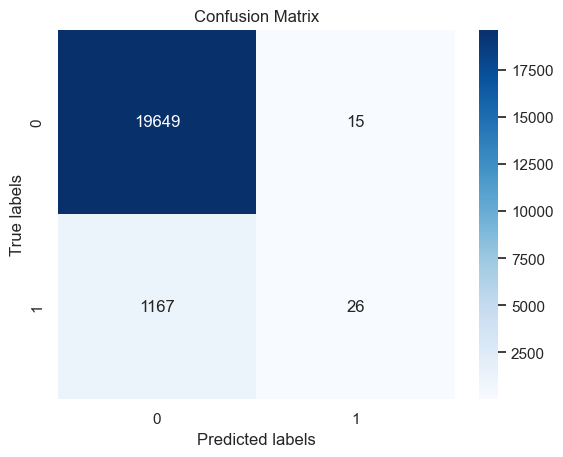

In [411]:
cm = confusion_matrix(y_test_final, test_preds_bagging)

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

**XGBoost**

In [396]:
# Define the XGBoost classifier
xgb_classifier = XGBClassifier(random_state=42)

# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_child_weight': [3, 5, 7],
    'learning_rate': [0.1, 0.3, 0.5],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0],
    'scale_pos_weight': [np.sum(y_train_final == 0)/sum(y_train_final == 1)]
}

# Perform GridSearchCV to find the best combination of hyperparameters
grid_search = GridSearchCV(estimator=xgb_classifier, param_grid=param_grid, cv=5, scoring='roc_auc', verbose=1)
grid_search.fit(X_train_final, y_train_final)

# Print the best parameters found
print("Best parameters:", grid_search.best_params_)

# Get the best XGBoost classifier
best_xgb_classifier = grid_search.best_estimator_

# Make predictions on the test set
test_preds_xgb = best_xgb_classifier.predict(X_test_final)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 7, 'n_estimators': 200, 'scale_pos_weight': 16.254601861427094, 'subsample': 1.0}


In [399]:
# Print performance measures
print(f'Accuracy: {accuracy_score(y_test_final, test_preds_xgb)}')
print(f'ROC AUC: {roc_auc_score(y_test_final, test_preds_xgb)}')
print(f'F1 score: {f1_score(y_test_final, test_preds_xgb)}')
print(f'Precision: {precision_score(y_test_final, test_preds_xgb)}')
print(f'Recall: {recall_score(y_test_final, test_preds_xgb)}')
print(f'Confusion matrix:\n{confusion_matrix(y_test_final, test_preds_xgb)}')


Accuracy: 0.8020808361701107
ROC AUC: 0.7576407919604254
F1 score: 0.29023383768913347
Precision: 0.18256543370105993
Recall: 0.7074601844090528
Confusion matrix:
[[15885  3779]
 [  349   844]]


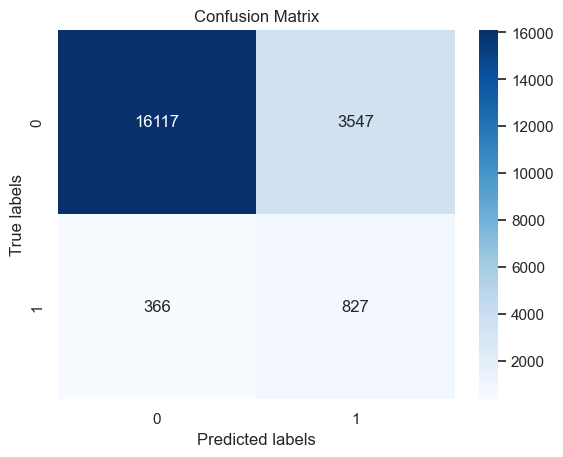

In [370]:
# Calculate confusion matrix
cm = confusion_matrix(y_test_final, test_preds_xgb)

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

**HistGradientBoosting**

In [417]:
# Define the HistGradientBoostingClassifier
hist_gb_classifier = HistGradientBoostingClassifier(random_state=42)

# Define the grid of hyperparameters to search
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [1, 2, 4],
    'l2_regularization': [0.0, 0.1, 0.5],
    'class_weight': ['balanced']
}

# Perform GridSearchCV to find the best combination of hyperparameters
grid_search = GridSearchCV(estimator=hist_gb_classifier, param_grid=param_grid, cv=5, scoring='roc_auc', verbose=1)
grid_search.fit(X_train_final, y_train_final)

# Print the best parameters found
print("Best parameters:", grid_search.best_params_)

# Get the best HistGradientBoostingClassifier
best_hist_gb_classifier = grid_search.best_estimator_

# Make predictions on the test set
test_preds_hist_gb = best_hist_gb_classifier.predict(X_test_final)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'class_weight': 'balanced', 'l2_regularization': 0.5, 'learning_rate': 0.01, 'max_depth': 7, 'max_iter': 300, 'min_samples_leaf': 2}


In [372]:
# Print performance measures
print(f'Accuracy: {accuracy_score(y_test_final, test_preds_hist_gb)}')
print(f'ROC AUC: {roc_auc_score(y_test_final, test_preds_hist_gb)}')
print(f'F1 score: {f1_score(y_test_final, test_preds_hist_gb)}')
print(f'Precision: {precision_score(y_test_final, test_preds_hist_gb)}')
print(f'Recall: {recall_score(y_test_final, test_preds_hist_gb)}')
print(f'Confusion matrix:\n{confusion_matrix(y_test_final, test_preds_hist_gb)}')


Accuracy: 0.8003068514167905
ROC AUC: 0.7519757747424118
F1 score: 0.2854692056956596
Precision: 0.17946505608283003
Recall: 0.6974015088013411
Confusion matrix:
[[15860  3804]
 [  361   832]]


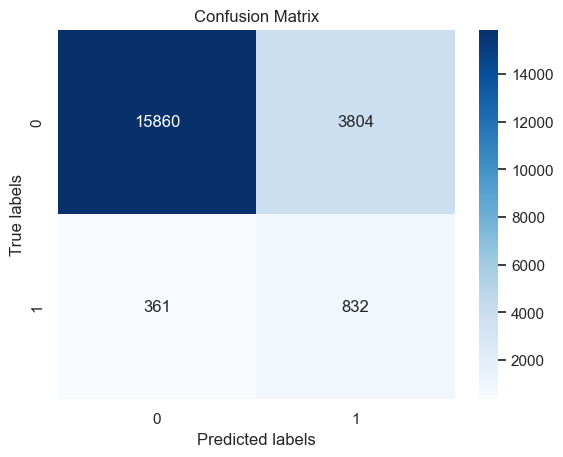

In [373]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, test_preds_hist_gb)

# Plot confusion matrix as heatmap
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

We plot the ROC and F1 score of the four classifiers to compare performances

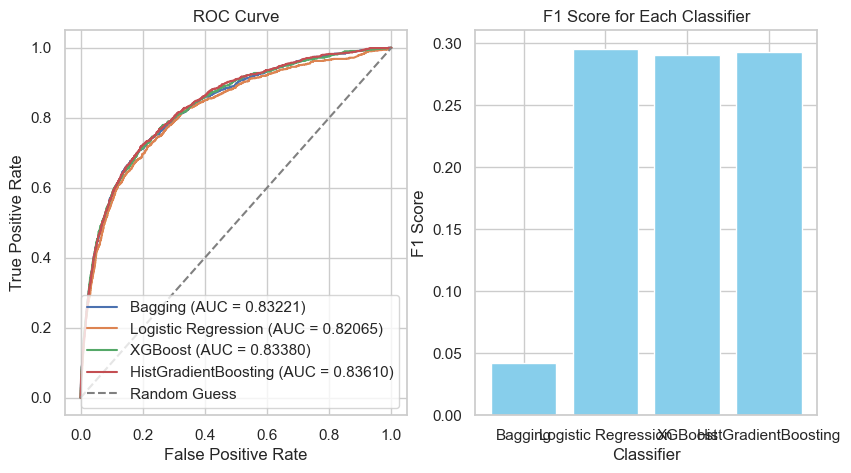

In [418]:
# Define classifiers and their predicted labels
classifiers_preds = {
    'Bagging': test_preds_bagging,
    'Logistic Regression': test_preds_lr,
    'XGBoost': test_preds_xgb,
    'HistGradientBoosting': test_preds_hist_gb
}

plt.figure(figsize=(15, 5))

# Plot ROC curves
plt.subplot(1, 3, 1)

for name, y_score in classifiers_preds.items():
    # Calculate ROC curve
    if name == 'Logistic Regression':
        test_preds_proba = best_model_lr.predict_proba(X_test_final)
    elif name == 'Bagging':
        test_preds_proba = best_bagging_classifier.predict_proba(X_test_final)
    elif name == 'XGBoost':
        test_preds_proba = best_xgb_classifier.predict_proba(X_test_final)
    elif name == 'HistGradientBoosting':
        test_preds_proba = best_hist_gb_classifier.predict_proba(X_test_final)
    
    fpr, tpr, _ = roc_curve(y_test_final, test_preds_proba[:, 1])
    
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_test_final, test_preds_proba[:, 1])
    
    # Plot ROC curve with multiple points
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.5f})')

# Plot the diagonal line (random guess)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plot F1 scores
plt.subplot(1, 3, 2)

f1_scores = []
for name, y_pred in classifiers_preds.items():
    f1 = f1_score(y_test_final, y_pred)
    f1_scores.append(f1)

plt.bar(classifiers_preds.keys(), f1_scores, color='skyblue')
plt.xlabel('Classifier')
plt.ylabel('F1 Score')
plt.title('F1 Score for Each Classifier')

plt.show()


From these graphs, we observe that the two classifiers with better AUC score are XGBoost and HistGradientBoosting, while F1 score is better for Logistic Regression and XGBoost. We proceed with a more detailed tuning of the parameters of our two Boosting Classifiers, to improve their performance.

We start with XGBoost. We set parameters to the values we found as optimum with the previous coarse grid search cross validation, and start fine-tuning with the parameter n_estimators

In [419]:
def modelfit(alg, X_train, y_train, useTrainCV=True, cv_folds=5, early_stopping_rounds=50):

    if useTrainCV:
        xgb_param = alg.get_xgb_params()
        xgtrain = xgb.DMatrix(X_train, label=y_train)
        cvresult = xgb.cv(xgb_param, xgtrain, num_boost_round=alg.get_params()['n_estimators'], nfold=cv_folds,
            metrics='auc', early_stopping_rounds=early_stopping_rounds)
        alg.set_params(n_estimators=cvresult.shape[0])

    #Fit the algorithm on the data
    alg.fit(X_train, y_train, eval_metric='auc')

    #Predict training set:
    dtrain_predictions = alg.predict(X_train)
    dtrain_predprob = alg.predict_proba(X_train)[:,1]

    #Print model report:
    print(alg.n_estimators)

xgb1 = xgb.XGBClassifier(
    learning_rate =0.1,
    n_estimators=5000,
    max_depth=3,
    min_child_weight = 7, 
    subsample=1,
    colsample_bytree=0.5,
    objective= 'binary:logistic',
    nthread=4,
    scale_pos_weight=np.sum(y_train_final == 0)/sum(y_train_final == 1),
    seed=27)

modelfit(alg=xgb1, X_train=X_train_final, y_train=y_train_final)


128


We observed that the optimum value for the number of trees is 128. Now, we perform cross validation to tune other parameters. To start with, we analyse min_child_depth and min_child_weight first as they will have the highest impact on the model outcome. We had already performed a coarse grid search, so now we analyse a smaller values for max_depth and hgiher values for min_child_weight

In [420]:
param_test1 = {
    'max_depth': range(1, 5),
    'min_child_weight': range(6, 9)
}

gsearch1 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate =0.1,
        n_estimators=128,
        max_depth=3,
        min_child_weight = 7, 
        subsample=1,
        colsample_bytree=0.5,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight=np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test1,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch1.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch1.best_params_)
print("Best score:", gsearch1.best_score_)



Best parameters: {'max_depth': 3, 'min_child_weight': 7}
Best score: 0.8338872273597359


The values we get are: max_depth = 3, min_child_weight = 7 again. We proceed with tuning of gamma, that we hadn't tuned before. We start with fewer values to see if the algorithm performs better with small or medium gammas.

In [422]:
param_test2 = {
    'gamma': [i / 2 for i in range(0, 11)]
}

gsearch2 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=128,
        max_depth=3,
        min_child_weight=7,
        gamma=0,
        subsample=1,
        colsample_bytree=0.5,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test2,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch2.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch2.best_params_)
print("Best score:", gsearch2.best_score_)


Best parameters: {'gamma': 1.0}
Best score: 0.8338964316524351


We got an optimal value of 1.0, we now analyse a smaller interval around this value

In [423]:
param_test3 = {
    'gamma': [i / 10 for i in range(5, 15)]
}

gsearch3 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate =0.1,
        n_estimators=128,
        max_depth=3,
        min_child_weight = 7, 
        subsample=1,
        colsample_bytree=0.5,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test3,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch3.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch3.best_params_)
print("Best score:", gsearch3.best_score_)


Best parameters: {'gamma': 1.3}
Best score: 0.8338972343206622


From our analysis, the optimum value of gamma is now 1.3.
Before proceeding, we re-calibrate the n_estimators prameter

In [426]:
xgb2 = XGBClassifier(
learning_rate =0.1,
n_estimators=5000,
max_depth=3,
min_child_weight = 7, 
gamma = 1.3,
subsample=1,
colsample_bytree=0.5,
 objective='binary:logistic',
 nthread=4,
 scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
 seed=27)
modelfit(xgb2, X_train_final, y_train_final)

123


We decrease n_estimators to 123 and proceed with our analysis of parameters subsample and colsample_bytree, looking at a smaller interval around the value we found with our coarse grid search

In [427]:
param_test4 = {
     'subsample':[i/10 for i in range(7,10)],
 'colsample_bytree':[i/10 for i in range(5,8)]
}

gsearch4 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=1,
        colsample_bytree=0.5,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test4,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch4.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch4.best_params_)
print("Best score:", gsearch4.best_score_)


Best parameters: {'colsample_bytree': 0.7, 'subsample': 0.7}
Best score: 0.8341375009924313


Finally, we repeat the analysis one more time, concentrating on a smaller interval

In [429]:
param_test5 = {
     'subsample':[i/100 for i in range(65, 75)],
 'colsample_bytree':[i/100 for i in range(65,75)]
}

gsearch5 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=1,
        colsample_bytree=0.5,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test5,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch5.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch5.best_params_)
print("Best score:", gsearch5.best_score_)


Best parameters: {'colsample_bytree': 0.67, 'subsample': 0.67}
Best score: 0.8342956496025652


The value we got are colsample_bytree = 0.67, subsample = 0.67. Now we search for the optimum value of alpha, starting from 7 values in range 10^-5 - 10^2

In [430]:
param_test6 = {
     'reg_alpha': [1e-5, 1e-2, 0.1, 1, 10, 50, 100]
}

gsearch6 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test7,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch6.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch6.best_params_)
print("Best score:", gsearch6.best_score_)


Best parameters: {'reg_alpha': 10}
Best score: 0.8345489633399465


The optimal value we got is 10, so we analyse more thoughly in the range 5-15

In [431]:
param_test7 = {
    'reg_alpha': range(5, 16)
}

gsearch7 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test7,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch7.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch7.best_params_)
print("Best score:", gsearch7.best_score_)


Best parameters: {'reg_alpha': 14}
Best score: 0.8348361284928314


The value we got is 14. We repeat this analysis for parameter lambda, starting from ten values between 0 and 10

In [432]:
param_test8 = {
    'reg_lambda': [0.0001,0.001,0.01,0.1,1,2,4,6,8,10]
}

gsearch8 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        reg_alpha = 14,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test8,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch8.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch8.best_params_)
print("Best score:", gsearch8.best_score_)


Best parameters: {'reg_lambda': 10}
Best score: 0.8349469691853708


As we got 10 as the optimum value, so look at an igher interval

In [434]:
param_test9 = {
    'reg_lambda': range(9, 15)
}

gsearch9 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        reg_alpha = 14,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test9,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch9.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch9.best_params_)
print("Best score:", gsearch9.best_score_)

Best parameters: {'reg_lambda': 10}
Best score: 0.8349469691853708


We got 10 again. Lastly, we look at a smaller interval

In [435]:
param_test10 = {
    'reg_lambda': [x/10 for x in range(95, 106)]
}

gsearch10 = GridSearchCV(
    estimator=XGBClassifier(
        learning_rate=0.1,
        n_estimators=123,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        reg_alpha = 14,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27
    ),
    param_grid=param_test10,
    scoring='roc_auc',
    n_jobs=4,
    cv=5
)

gsearch10.fit(X_train_final, y_train_final)

print("Best parameters:", gsearch10.best_params_)
print("Best score:", gsearch10.best_score_)

Best parameters: {'reg_lambda': 10.0}
Best score: 0.8349469691853708


We got 10. We re-calibrate the n_estimators parameters one last time, lowering the learning rate

In [437]:
xgb3 = XGBClassifier(
        learning_rate=0.01,
        n_estimators=5000,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        reg_alpha = 14,
        reg_lambda = 10,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27)
modelfit(xgb3, X_train_final, y_train_final)

1333


Now, we fit our trained model onto our test dataset to observe its performance

In [438]:

xgb_final = XGBClassifier(
        learning_rate=0.01,
        n_estimators=1333,
        max_depth=3,
        min_child_weight=7,
        gamma = 1.3,
        subsample=0.67,
        colsample_bytree=0.67,
        reg_alpha = 14,
        reg_lambda = 10,
        objective='binary:logistic',
        nthread=4,
        scale_pos_weight= np.sum(y_train_final == 0)/sum(y_train_final == 1),
        seed=27)
xgb_final.fit(X_train_final, y_train_final)
test_preds = xgb_final.predict(X_test_final)


#Performance measures on test_preds
print(f'Accuracy: {accuracy_score(y_test_final, test_preds)}')
print(f'ROC AUC: {roc_auc_score(y_test_final, test_preds)}')
print(f'F1 score: {f1_score(y_test_final, test_preds)}')
print(f'Precision: {precision_score(y_test_final, test_preds)}')
print(f'Recall: {recall_score(y_test_final, test_preds)}')
print(f'Confusion matrix: {confusion_matrix(y_test_final, test_preds)}')

Accuracy: 0.8018890540346166
ROC AUC: 0.7587201361754253
F1 score: 0.29076553381393755
Precision: 0.18281890783509605
Recall: 0.7099748533109808
Confusion matrix: [[15878  3786]
 [  346   847]]


We plot the ROC curve and f1 score to compare the performance of the XGBoost CLassifier before and after the more detailed tuining

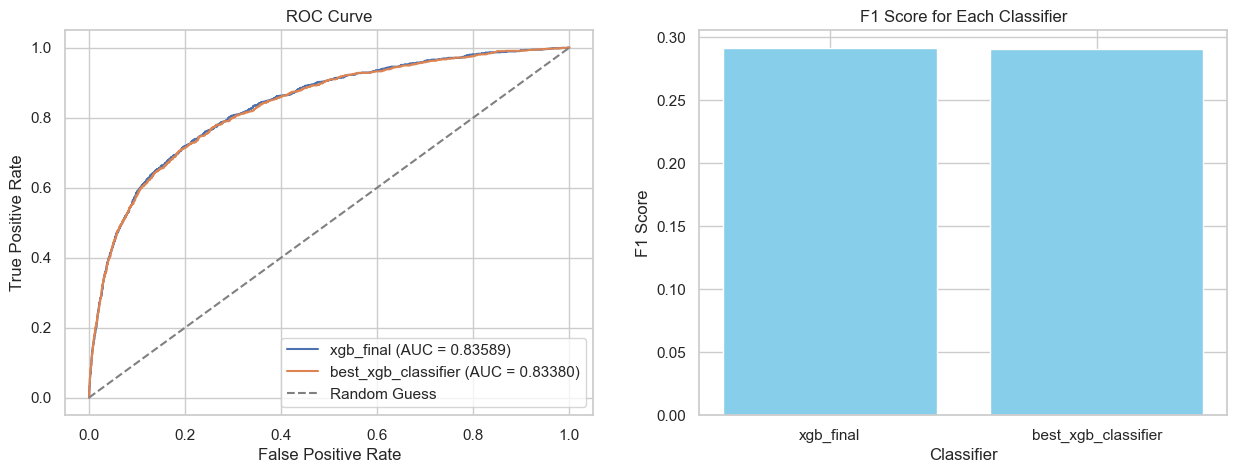

In [439]:
plt.figure(figsize=(15, 5))

# Plot ROC curves
plt.subplot(1, 2, 1)

for name, model in [('xgb_final', xgb_final), ('best_xgb_classifier', best_xgb_classifier)]:
    # Calculate predicted probabilities on the test data
    test_preds_proba = model.predict_proba(X_test_final)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test_final, test_preds_proba[:, 1])
    
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_test_final, test_preds_proba[:, 1])
    
    # Plot ROC curve with multiple points
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.5f})')

# Plot the diagonal line (random guess)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plot F1 scores
plt.subplot(1, 2, 2)

f1_scores = []
for name, model in [('xgb_final', xgb_final), ('best_xgb_classifier', best_xgb_classifier)]:
    # Calculate predicted labels on the test data
    test_preds = model.predict(X_test_final)
    
    f1 = f1_score(y_test_final, test_preds)
    f1_scores.append(f1)

plt.bar(['xgb_final', 'best_xgb_classifier'], f1_scores, color='skyblue')
plt.xlabel('Classifier')
plt.ylabel('F1 Score')
plt.title('F1 Score for Each Classifier')

plt.show()


We apply a similar approach to HistGradientBoosting. As we did for XGBoost, we set the values obtained with the coarse grid search cross validation. We start by tuning max_iter

In [440]:
param_test1 = {'max_iter':range(50, 150, 10)}

gsearch1 = GridSearchCV(estimator = HistGradientBoostingClassifier(learning_rate=0.01, 
                                                               min_samples_leaf=2,
                                                               max_depth=7,
                                                               l2_regularization = 0.5,
                                                               class_weight = 'balanced',
                                                               random_state=27), 
                        param_grid = param_test1, scoring='roc_auc',n_jobs=4, cv=5)
gsearch1.fit(X_train_final, y_train_final)
print("Best parameters:", gsearch1.best_params_)
print("Best score:", gsearch1.best_score_)


Best parameters: {'max_iter': 140}
Best score: 0.8335621772993557


Now we move onto tuning the tree parameters. We start by tuning max_depth. As we got the highest bound as a result, we first analyse the interval 6-10

In [441]:
param_test2 = {'max_depth':range(6,11)}

gsearch2 = GridSearchCV(estimator = HistGradientBoostingClassifier(learning_rate=0.01, 
                                                                max_iter= 140,
                                                               min_samples_leaf=2,
                                                               max_depth=7,
                                                               l2_regularization = 0.5,
                                                               class_weight = 'balanced',
                                                               random_state=27), 
                        param_grid = param_test2, scoring='roc_auc',n_jobs=4, cv=5)
gsearch2.fit(X_train_final, y_train_final)
print("Best parameters:", gsearch2.best_params_)
print("Best score:", gsearch2.best_score_)

Best parameters: {'max_depth': 6}
Best score: 0.8336965781366631


We got 6. For min_samples_leaf, we got 2, which is plausible, so we move to l2_regularization. As our currennt value is the highest we got in our coarse grid search, we first try some larger values

In [443]:
param_test3 = {'l2_regularization': [0.5, 1, 2, 5, 10]}

gsearch3 = GridSearchCV(estimator = HistGradientBoostingClassifier(learning_rate=0.01, 
                                                                max_iter= 140,
                                                               min_samples_leaf=2,
                                                               max_depth=6,
                                                               l2_regularization = 0.5,
                                                               class_weight = 'balanced',
                                                               random_state=27), 
                        param_grid = param_test3, scoring='roc_auc',n_jobs=4, cv=5)
gsearch3.fit(X_train_final, y_train_final)
print("Best parameters:", gsearch3.best_params_)
print("Best score:", gsearch3.best_score_)

Best parameters: {'l2_regularization': 5}
Best score: 0.8338129105456009


We got 5, hence we look better in the interval 4-8

In [445]:
param_test4 = {'l2_regularization': [4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8]}

gsearch4 = GridSearchCV(estimator = HistGradientBoostingClassifier(learning_rate=0.01, 
                                                                max_iter= 140,
                                                               min_samples_leaf=2,
                                                               max_depth=6,
                                                               l2_regularization = 0.5,
                                                               class_weight = 'balanced',
                                                               random_state=27), 
                        param_grid = param_test4, scoring='roc_auc',n_jobs=4, cv=5)
gsearch4.fit(X_train_final, y_train_final)
print("Best parameters:", gsearch4.best_params_)
print("Best score:", gsearch4.best_score_)

Best parameters: {'l2_regularization': 4.5}
Best score: 0.8338419302174664


Now, we lower the learning rate and re-calibrate max_iter

In [447]:
param_test5 = {'max_iter': [100, 300, 500, 1000]}

gsearch5 = GridSearchCV(estimator = HistGradientBoostingClassifier(learning_rate=0.001, 
                                                                max_iter= 140,
                                                               min_samples_leaf=2,
                                                               max_depth=6,
                                                               l2_regularization = 4.5,
                                                               class_weight = 'balanced',
                                                               random_state=27), 
                        param_grid = param_test5, scoring='roc_auc',n_jobs=4, cv=5)
gsearch5.fit(X_train_final, y_train_final)
print("Best parameters:", gsearch5.best_params_)
print("Best score:", gsearch5.best_score_)

Best parameters: {'max_iter': 1000}
Best score: 0.8326335909852105


We fit our final model ont the test set

In [448]:

hist_gb_final = HistGradientBoostingClassifier(learning_rate=0.001, 
                                                max_iter= 1000,
                                                min_samples_leaf=2,
                                                max_depth=6,
                                                l2_regularization = 4.5,
                                                class_weight = 'balanced',
                                                random_state=27)
hist_gb_final.fit(X_train_final, y_train_final)
test_preds = hist_gb_final.predict(X_test_final)


#Performance measures on test_preds
print(f'Accuracy: {accuracy_score(y_test_final, test_preds)}')
print(f'ROC AUC: {roc_auc_score(y_test_final, test_preds)}')
print(f'F1 score: {f1_score(y_test_final, test_preds)}')
print(f'Precision: {precision_score(y_test_final, test_preds)}')
print(f'Recall: {recall_score(y_test_final, test_preds)}')
print(f'Confusion matrix: {confusion_matrix(y_test_final, test_preds)}')

Accuracy: 0.7993479407393201
ROC AUC: 0.7573724958174107
F1 score: 0.2881442422180643
Precision: 0.1807511737089202
Recall: 0.7099748533109808
Confusion matrix: [[15825  3839]
 [  346   847]]


We plot the ROC curve and f1 score to compare the performance of HistGradientBoostingCLassifier before and after the more detailed tuining

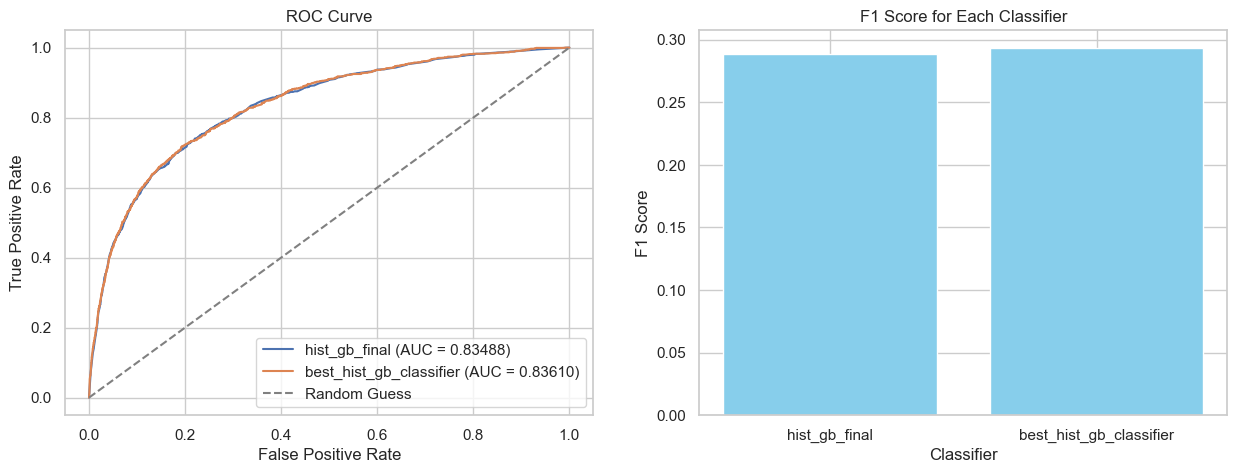

In [449]:
plt.figure(figsize=(15, 5))

# Plot ROC curves
plt.subplot(1, 2, 1)

for name, model in [('hist_gb_final', hist_gb_final), ('best_hist_gb_classifier', best_hist_gb_classifier)]:
    # Calculate predicted probabilities on the test data
    test_preds_proba = model.predict_proba(X_test_final)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test_final, test_preds_proba[:, 1])
    
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_test_final, test_preds_proba[:, 1])
    
    # Plot ROC curve with multiple points
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.5f})')

# Plot the diagonal line (random guess)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plot F1 scores
plt.subplot(1, 2, 2)

f1_scores = []
for name, model in [('hist_gb_final', hist_gb_final), ('best_hist_gb_classifier', best_hist_gb_classifier)]:
    # Calculate predicted labels on the test data
    test_preds = model.predict(X_test_final)
    
    f1 = f1_score(y_test_final, test_preds)
    f1_scores.append(f1)

plt.bar(['hist_gb_final', 'best_hist_gb_classifier'], f1_scores, color='skyblue')
plt.xlabel('Classifier')
plt.ylabel('F1 Score')
plt.title('F1 Score for Each Classifier')

plt.show()


We observe a decrease in performance after the tuning, so we keep the previous model.
Now, we compare the results obtained by the best performing XGBoost Classifier and HistGradientBoostingClassifier

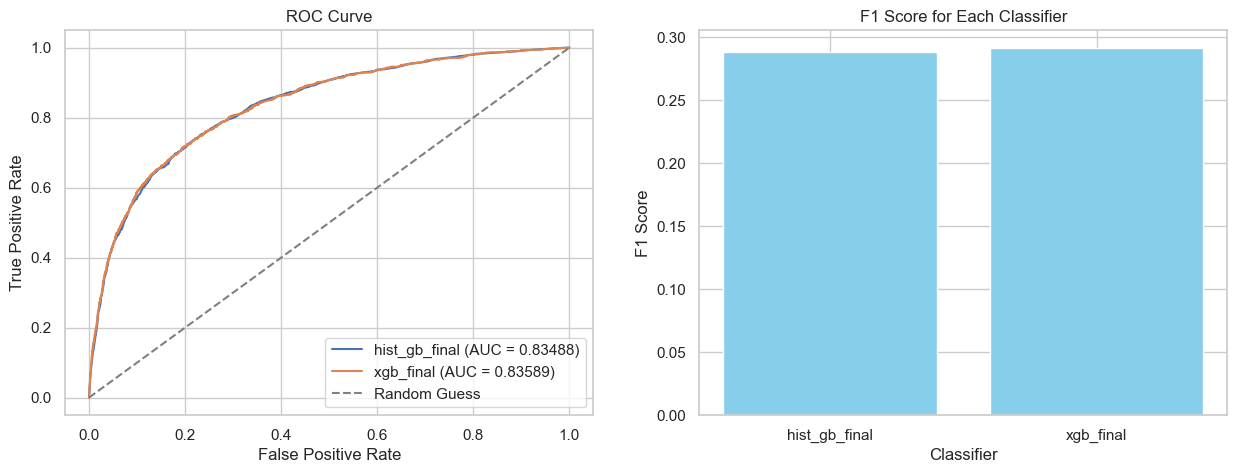

In [450]:
plt.figure(figsize=(15, 5))

# Plot ROC curves
plt.subplot(1, 2, 1)

for name, model in [('hist_gb_final', hist_gb_final), ('xgb_final', xgb_final)]:
    # Calculate predicted probabilities on the test data
    test_preds_proba = model.predict_proba(X_test_final)
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test_final, test_preds_proba[:, 1])
    
    # Calculate ROC AUC score
    roc_auc = roc_auc_score(y_test_final, test_preds_proba[:, 1])
    
    # Plot ROC curve with multiple points
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.5f})')

# Plot the diagonal line (random guess)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Plot F1 scores
plt.subplot(1, 2, 2)

f1_scores = []
for name, model in [('hist_gb_final', hist_gb_final), ('xgb_final', xgb_final)]:
    # Calculate predicted labels on the test data
    test_preds = model.predict(X_test_final)
    
    f1 = f1_score(y_test_final, test_preds)
    f1_scores.append(f1)

plt.bar(['hist_gb_final', 'xgb_final'], f1_scores, color='skyblue')
plt.xlabel('Classifier')
plt.ylabel('F1 Score')
plt.title('F1 Score for Each Classifier')

plt.show()


Based on these results, we choose XGBClassifier as the best classifier of our problem. We proceed to fit it to the test dataset we were provided

In [463]:
#loading data
data_test = pd.read_csv("test.csv")

First, we must prepare the dataset for classification, applying modifications we made to the training dataset. We start by observing percentages of NAs

In [464]:
# Calculate the percentage of missing values for each column
missing_percentages = data_test.isnull().mean() * 100

# Print the percentage of NAs for each feature
for feature, percentage in missing_percentages.items():
    print(f'{feature}: {percentage:.2f}% missing values')

Unnamed: 0: 0.00% missing values
RevolvingUtilizationOfUnsecuredLines: 0.00% missing values
age: 0.00% missing values
NumberOfTime30-59DaysPastDueNotWorse: 0.00% missing values
DebtRatio: 0.00% missing values
MonthlyIncome: 20.12% missing values
NumberOfOpenCreditLinesAndLoans: 0.00% missing values
NumberOfTimes90DaysLate: 0.00% missing values
NumberRealEstateLoansOrLines: 0.00% missing values
NumberOfTime60-89DaysPastDueNotWorse: 0.00% missing values
NumberOfDependents: 2.61% missing values


As our trianing dataset, NAs are present only in MonthlyIncome and NumberOfDependentsColumns. We proceed iwth imputing, using Iterative Imputer with RandomForests and median imputetation

In [465]:
#NUMBER OF DEPENDENTS
data_test["NumberOfDependents"].fillna(median_dependents, inplace=True)

In [466]:
#MONTLHY INCOME

columns_to_exclude = 'Unnamed: 0'  
data_test = data_test.drop(columns=columns_to_exclude)
imputed_data_test = final_imputer.transform(data_test)
# Convert the imputed data back to a DataFrame
data_test1 = pd.DataFrame(imputed_data_test, columns=data_test.columns)

Now, we add the additional feature that we created during Feature Engeneering

In [469]:
data_test_poly = poly.transform(data_test1[features_to_poly].copy())

# create a new dataframe with the polynomial features
data_test_poly = pd.DataFrame(data_test_poly, columns=poly.get_feature_names_out(features_to_poly))

# merge the data with the non-polynomial features
data_test_non_poly = data_test.drop(columns=features_to_poly)

data_test_poly[data_test_non_poly.columns] = data_test_non_poly.values
data_test_poly.head()
data_test1 = data_test_poly
data_test1['income_dependent'] = data_test1['MonthlyIncome'] / (data_test1['NumberOfDependents'] + 1)
data_test1['DelinquencyRatio'] = (data_test1['NumberOfTime30-59DaysPastDueNotWorse'] + data_test1['NumberOfTimes90DaysLate'] + data_test1['NumberOfTime60-89DaysPastDueNotWorse']) / (data_test1['NumberOfOpenCreditLinesAndLoans'] + 1)


We drop the columns that were dropped during Feature Selection and the ones that were dropped due to multicollinearity

In [470]:
data_test2 = data_test1[x_features_to_keep]
data_test2 = data_test2.drop(columns=features_to_drop)

Then, we scale

In [471]:
data_test_scaled = scaler.transform(data_test2)
data_test_final = pd.DataFrame(data_test_scaled, columns=data_test2.columns, index=data_test2.index)


Finally, we fit our classifier onto the test dataset

In [474]:
predictions = xgb_final.predict_proba(data_test_final)[:,1]
df_predictions = pd.DataFrame(predictions, columns=['Probability_Class'])
df_predictions.to_csv('submission.csv', index=False)